<a href="https://colab.research.google.com/github/daldowaihi/Beyond-Accuracy-Explanation-Instability-Under-Decision-Uncertainty-in-Credit-Risk-Classification/blob/main/Credit_XAI_Result_Visualized.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Beyond Accuracy: Explanation Instability Under Decision Uncertainty in Credit Risk Classification


| Component | Choice |
|---|---|
| **Models** | Random Forest (bagging) + Gradient Boosting (boosting) |
| **Explainers** | TreeSHAP + LIME |
| **Strata** | Confident-Correct · Borderline · Confident-Incorrect |
| **Experiments** | A: Perturbation stability · B: Cross-method agreement |
| **Headline metrics** | Spearman ρ + Top-5 Jaccard |
| **Statistical test** | Mann–Whitney U + Holm–Bonferroni + rank-biserial |
| **Reproducibility seed** | `random_state = 42` |


- **SHAP beeswarm summary plots** are produced for the test set, an example confident-correct instance, an example borderline instance — and **before vs. after perturbation** to see explanation instability.
- **Confusion matrices** are plotted as labelled heatmaps (not just printed).


## 1 · Environment setup

In [ ]:
# Install SHAP, LIME, LightGBM (Colab already ships numpy/pandas/sklearn/matplotlib/seaborn/scipy)
!pip -q install shap lime lightgbm


## 2 · Imports and reproducibility

In [ ]:
import argparse, json, logging, os, random, warnings
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import shap
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, balanced_accuracy_score,
    confusion_matrix, roc_curve, precision_recall_curve,
)
from sklearn.model_selection import train_test_split
from scipy import stats as sp_stats

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.WARNING, format="%(asctime)s [%(levelname)s] %(message)s")
log = logging.getLogger("optA")

# Seaborn aesthetics
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 140
plt.rcParams["axes.titleweight"] = "bold"

# Reproducibility (Methodology Section III-C)
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
print(f"SHAP version: {shap.__version__}")
print(f"Seed: {SEED}")


SHAP version: 0.51.0
Seed: 42


## 3 · Configuration

All experimental parameters from the methodology are gathered here for one-stop visibility. Switch `QUICK_MODE` to `True` for a fast smoke-test run.

In [ ]:
# ---- Quick-mode flag ------------------------------------------------------
QUICK_MODE = False  # set True for a ~3-5 min smoke test

# ---- Data split (Section III-C) -------------------------------------------
TRAIN_FRAC, VAL_FRAC, TEST_FRAC = 0.70, 0.15, 0.15

# ---- Stratum bands (Section III-E.1) --------------------------------------
CONFIDENT_LOW, CONFIDENT_HIGH = 0.20, 0.80
BORDERLINE_LOW, BORDERLINE_HIGH = 0.40, 0.60

# ---- Perturbation protocol (Section III-E.2) ------------------------------
N_PERTURBATIONS = 30
PERTURB_SIGMA_HEADLINE = 0.03
PERTURB_SIGMA_GRID = (0.01, 0.03, 0.05)
ORDINAL_SHIFT_PROB = 0.20
PRED_STABILITY_FILTER = 0.05  # |Δp̂| < 0.05

# ---- Sampling -------------------------------------------------------------
INSTANCES_PER_STRATUM = 100

# ---- LIME -----------------------------------------------------------------
LIME_NUM_SAMPLES = 5000

# ---- Statistical tests (Section III-H) ------------------------------------
REFERENCE_STRATUM = "confident_correct"
ALPHA = 0.05

# ---- Apply quick mode -----------------------------------------------------
if QUICK_MODE:
    INSTANCES_PER_STRATUM = 20
    N_PERTURBATIONS = 10
    LIME_NUM_SAMPLES = 1000
    PERTURB_SIGMA_GRID = (0.03,)
    print("[QUICK MODE ON]")

# ---- Output paths ---------------------------------------------------------
OUTPUT_DIR = Path("outputs")
TABLES_DIR = OUTPUT_DIR / "tables"
FIGURES_DIR = OUTPUT_DIR / "figures"
MODELS_DIR = OUTPUT_DIR / "models"
for d in (TABLES_DIR, FIGURES_DIR, MODELS_DIR):
    d.mkdir(parents=True, exist_ok=True)

# Stratum colors used everywhere
STRATUM_COLORS = {
    "confident_correct":   "#2E8B57",  # sea-green
    "borderline":          "#E69F00",  # amber
    "confident_incorrect": "#C0392B",  # crimson
}
STRATUM_ORDER = ["confident_correct", "borderline", "confident_incorrect"]

print(f"INSTANCES_PER_STRATUM = {INSTANCES_PER_STRATUM}")
print(f"N_PERTURBATIONS       = {N_PERTURBATIONS}")
print(f"PERTURB_SIGMA_GRID    = {PERTURB_SIGMA_GRID}")
print(f"OUTPUT_DIR            = {OUTPUT_DIR.resolve()}")


INSTANCES_PER_STRATUM = 100
N_PERTURBATIONS       = 30
PERTURB_SIGMA_GRID    = (0.01, 0.03, 0.05)
OUTPUT_DIR            = /content/outputs


## 4 · Data loading and 70/15/15 split

Loads the UCI *Default of Credit Card Clients* dataset (Yeh & Lien, 2009) and applies the descriptive column-rename mapping documented in Appendix A. Splits 70/15/15 stratified by the target.

In [ ]:
COLUMN_RENAME = {
    "LIMIT_BAL": "Credit_Limit",
    "SEX": "Gender",
    "EDUCATION": "Education_Level",
    "MARRIAGE": "Marital_Status",
    "AGE": "Age",
    "PAY_0": "RepayDelay_Sep", "PAY_2": "RepayDelay_Aug",
    "PAY_3": "RepayDelay_Jul", "PAY_4": "RepayDelay_Jun",
    "PAY_5": "RepayDelay_May", "PAY_6": "RepayDelay_Apr",
    "BILL_AMT1": "BillAmt_Sep", "BILL_AMT2": "BillAmt_Aug",
    "BILL_AMT3": "BillAmt_Jul", "BILL_AMT4": "BillAmt_Jun",
    "BILL_AMT5": "BillAmt_May", "BILL_AMT6": "BillAmt_Apr",
    "PAY_AMT1": "Payment_Sep", "PAY_AMT2": "Payment_Aug",
    "PAY_AMT3": "Payment_Jul", "PAY_AMT4": "Payment_Jun",
    "PAY_AMT5": "Payment_May", "PAY_AMT6": "Payment_Apr",
}

CONTINUOUS_FEATURES = [
    "Credit_Limit", "Age",
    "BillAmt_Sep", "BillAmt_Aug", "BillAmt_Jul",
    "BillAmt_Jun", "BillAmt_May", "BillAmt_Apr",
    "Payment_Sep", "Payment_Aug", "Payment_Jul",
    "Payment_Jun", "Payment_May", "Payment_Apr",
]
ORDINAL_FEATURES = [
    "RepayDelay_Sep", "RepayDelay_Aug", "RepayDelay_Jul",
    "RepayDelay_Jun", "RepayDelay_May", "RepayDelay_Apr",
]
CATEGORICAL_FEATURES = ["Gender", "Education_Level", "Marital_Status"]
ALL_FEATURES = CONTINUOUS_FEATURES + ORDINAL_FEATURES + CATEGORICAL_FEATURES


def load_uci_dataset() -> pd.DataFrame:
    import urllib.request
    p = Path("data/default_of_credit_card_clients.xls")
    p.parent.mkdir(parents=True, exist_ok=True)
    if not p.exists():
        url = ("https://archive.ics.uci.edu/ml/machine-learning-databases/00350/"
               "default%20of%20credit%20card%20clients.xls")
        print(f"Downloading UCI dataset → {p}")
        urllib.request.urlretrieve(url, p)
    df = pd.read_excel(p, header=1)
    df = df.rename(columns={"default payment next month": "default", **COLUMN_RENAME})
    if "ID" in df.columns:
        df = df.drop(columns=["ID"])
    df.loc[df["Education_Level"].isin([0, 5, 6]), "Education_Level"] = 4
    df.loc[df["Marital_Status"] == 0, "Marital_Status"] = 3
    print(f"Loaded {len(df)} rows, default rate={df['default'].mean():.3f}")
    return df


def split_data(df: pd.DataFrame, seed: int = SEED):
    X = df[ALL_FEATURES].copy()
    y = df["default"].astype(int).values
    X_trainval, X_test, y_trainval, y_test = train_test_split(
        X, y, test_size=TEST_FRAC, stratify=y, random_state=seed
    )
    val_share = VAL_FRAC / (TRAIN_FRAC + VAL_FRAC)
    X_train, X_val, y_train, y_val = train_test_split(
        X_trainval, y_trainval, test_size=val_share,
        stratify=y_trainval, random_state=seed,
    )
    print(f"Train {len(X_train)} (def={y_train.mean():.3f}), "
          f"Val {len(X_val)} (def={y_val.mean():.3f}), "
          f"Test {len(X_test)} (def={y_test.mean():.3f})")
    return X_train, X_val, X_test, y_train, y_val, y_test


df = load_uci_dataset()
X_train, X_val, X_test, y_train, y_val, y_test = split_data(df)

# ── Preview the raw dataframe ─────────────────────────────────────────────
print("\nRaw dataset — head():")
display(df.head())
print(f"\nShape: {df.shape}")
print(f"\nFeature dtypes:")
display(df.dtypes.to_frame("dtype").head(10))


Loaded 30000 rows, default rate=0.221
Train 21000 (def=0.221), Val 4500 (def=0.221), Test 4500 (def=0.221)

Raw dataset — head():


,Credit_Limit,Gender,Education_Level,Marital_Status,Age,RepayDelay_Sep,RepayDelay_Aug,RepayDelay_Jul,RepayDelay_Jun,RepayDelay_May,...,BillAmt_Jun,BillAmt_May,BillAmt_Apr,Payment_Sep,Payment_Aug,Payment_Jul,Payment_Jun,Payment_May,Payment_Apr,default
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0



Shape: (30000, 24)

Feature dtypes:


,dtype
Credit_Limit,int64
Gender,int64
Education_Level,int64
Marital_Status,int64
Age,int64
RepayDelay_Sep,int64
RepayDelay_Aug,int64
RepayDelay_Jul,int64
RepayDelay_Jun,int64
RepayDelay_May,int64


### 4.1 · Exploratory visualizations of the raw data

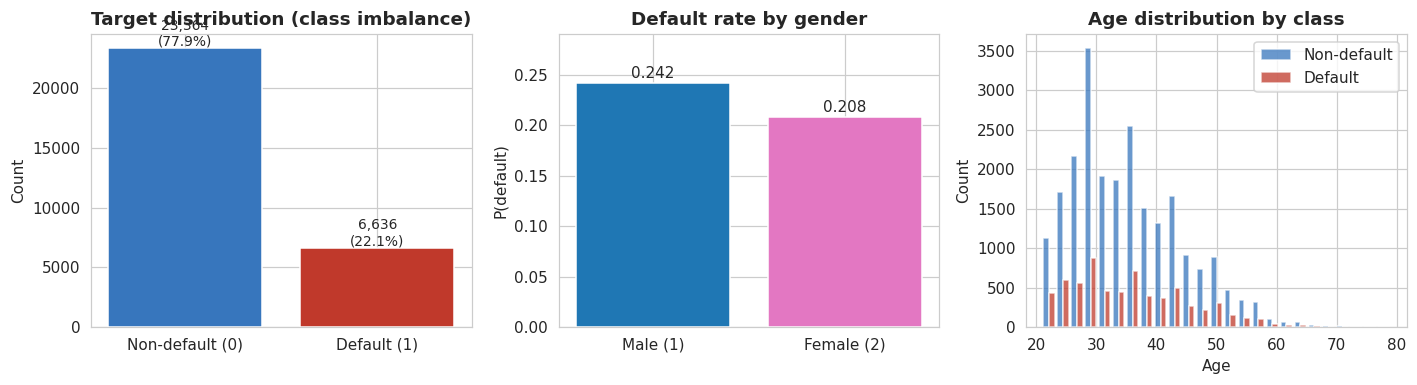

In [ ]:
# ---- (a) Target balance + (b) demographic splits ------------------------
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))

# Target distribution
target_counts = df["default"].value_counts().sort_index()
axes[0].bar(["Non-default (0)", "Default (1)"], target_counts.values,
            color=["#3776BD", "#C0392B"])
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 200, f"{v:,}\n({v/len(df)*100:.1f}%)",
                 ha="center", fontsize=9)
axes[0].set_title("Target distribution (class imbalance)")
axes[0].set_ylabel("Count")

# Default rate by gender
gender_def = df.groupby("Gender")["default"].mean()
axes[1].bar(["Male (1)", "Female (2)"], gender_def.values,
            color=["#1f77b4", "#e377c2"])
for i, v in enumerate(gender_def.values):
    axes[1].text(i, v + 0.005, f"{v:.3f}", ha="center", fontsize=10)
axes[1].set_title("Default rate by gender")
axes[1].set_ylabel("P(default)")
axes[1].set_ylim(0, max(gender_def.values) * 1.2)

# Age histogram colored by default
axes[2].hist([df.loc[df.default == 0, "Age"], df.loc[df.default == 1, "Age"]],
             bins=25, stacked=False, label=["Non-default", "Default"],
             color=["#3776BD", "#C0392B"], alpha=0.75)
axes[2].set_title("Age distribution by class")
axes[2].set_xlabel("Age"); axes[2].set_ylabel("Count")
axes[2].legend()

plt.tight_layout()
plt.show()


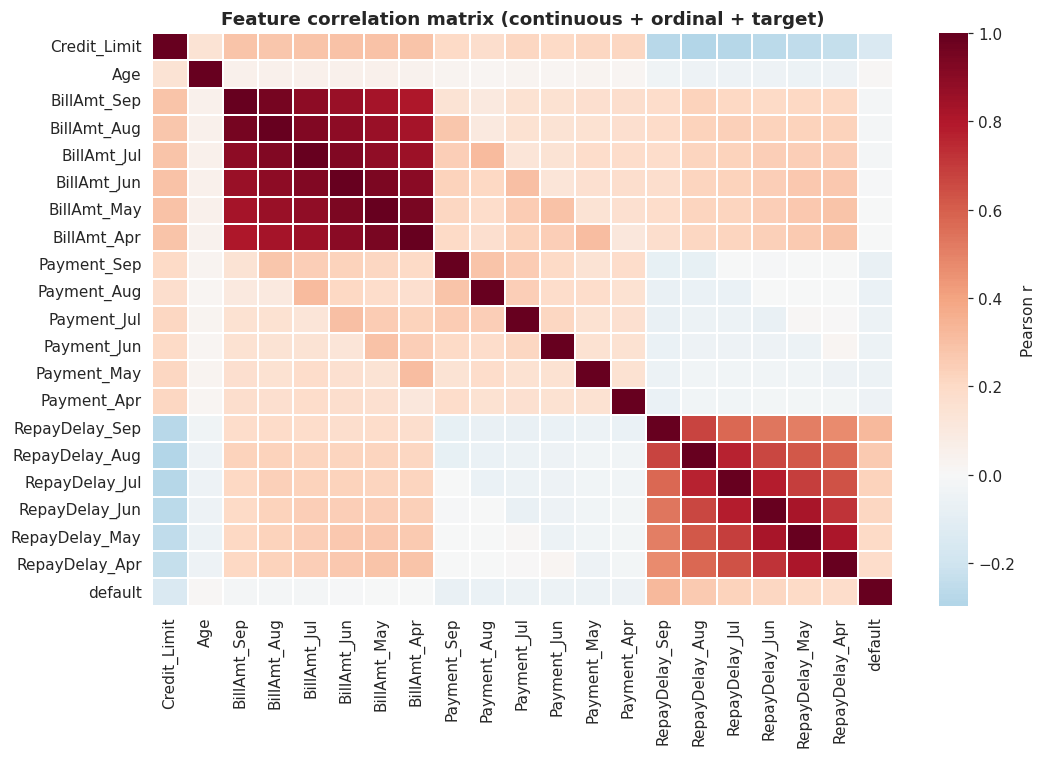


Top-10 features most correlated with `default`:


,corr_with_default
RepayDelay_Sep,0.324794
RepayDelay_Aug,0.263551
RepayDelay_Jul,0.235253
RepayDelay_Jun,0.216614
RepayDelay_May,0.204149
RepayDelay_Apr,0.186866
Credit_Limit,-0.153520
Payment_Sep,-0.072929
Payment_Aug,-0.058579
Payment_Jun,-0.056827


In [ ]:
# ---- Feature correlation heatmap (continuous features) -----------------
fig, ax = plt.subplots(figsize=(10, 7))
corr = df[CONTINUOUS_FEATURES + ORDINAL_FEATURES + ["default"]].corr()
sns.heatmap(corr, cmap="RdBu_r", center=0, annot=False,
            cbar_kws={"label": "Pearson r"}, ax=ax,
            linewidths=0.3, linecolor="white")
ax.set_title("Feature correlation matrix (continuous + ordinal + target)")
plt.tight_layout()
plt.show()

# Show top correlations with the target
target_corr = corr["default"].drop("default").sort_values(key=abs, ascending=False)
print("\nTop-10 features most correlated with `default`:")
display(target_corr.head(10).to_frame("corr_with_default"))


## 5 · Train Random Forest and Gradient Boosting

Both models share the same train/val/test split and use class-balanced weighting. A small validation grid is searched and the configuration with the highest validation AUC-ROC is kept.

In [ ]:
def train_random_forest(X_train, y_train, X_val, y_val, seed=SEED):
    grid = []
    for n_est in [500]:
        for max_d in [None, 10, 20]:
            for min_leaf in [1, 5, 10]:
                model = RandomForestClassifier(
                    n_estimators=n_est, max_depth=max_d, min_samples_leaf=min_leaf,
                    class_weight="balanced", n_jobs=-1, random_state=seed,
                )
                model.fit(X_train, y_train)
                p_val = model.predict_proba(X_val)[:, 1]
                auc = roc_auc_score(y_val, p_val)
                grid.append({
                    "model": "random_forest", "n_estimators": n_est,
                    "max_depth": max_d, "min_samples_leaf": min_leaf,
                    "val_auc_roc": auc,
                })
    grid_df = pd.DataFrame(grid).sort_values("val_auc_roc", ascending=False).reset_index(drop=True)
    best = grid_df.iloc[0]
    final = RandomForestClassifier(
        n_estimators=int(best["n_estimators"]),
        max_depth=None if pd.isna(best["max_depth"]) else int(best["max_depth"]),
        min_samples_leaf=int(best["min_samples_leaf"]),
        class_weight="balanced", n_jobs=-1, random_state=seed,
    )
    final.fit(X_train, y_train)
    return final, grid_df


def train_gradient_boosting(X_train, y_train, X_val, y_val, seed=SEED):
    try:
        from lightgbm import LGBMClassifier
        backend = "lightgbm"
    except ImportError:
        LGBMClassifier = None
        backend = "histgbm"
    print(f"GBM backend: {backend}")
    grid = []
    for n_est in [200, 500]:
        for max_d in [4, 6, 8]:
            for lr in [0.05, 0.10]:
                if backend == "lightgbm":
                    model = LGBMClassifier(
                        n_estimators=n_est, max_depth=max_d, learning_rate=lr,
                        class_weight="balanced", n_jobs=-1, random_state=seed,
                        verbose=-1,
                    )
                else:
                    model = HistGradientBoostingClassifier(
                        max_iter=n_est, max_depth=max_d, learning_rate=lr,
                        class_weight="balanced", random_state=seed,
                    )
                model.fit(X_train, y_train)
                p_val = model.predict_proba(X_val)[:, 1]
                auc = roc_auc_score(y_val, p_val)
                grid.append({
                    "model": "gradient_boosting", "n_estimators": n_est,
                    "max_depth": max_d, "learning_rate": lr,
                    "val_auc_roc": auc, "backend": backend,
                })
    grid_df = pd.DataFrame(grid).sort_values("val_auc_roc", ascending=False).reset_index(drop=True)
    best = grid_df.iloc[0]
    if backend == "lightgbm":
        from lightgbm import LGBMClassifier
        final = LGBMClassifier(
            n_estimators=int(best["n_estimators"]), max_depth=int(best["max_depth"]),
            learning_rate=float(best["learning_rate"]),
            class_weight="balanced", n_jobs=-1, random_state=seed, verbose=-1,
        )
    else:
        final = HistGradientBoostingClassifier(
            max_iter=int(best["n_estimators"]), max_depth=int(best["max_depth"]),
            learning_rate=float(best["learning_rate"]),
            class_weight="balanced", random_state=seed,
        )
    final.fit(X_train, y_train)
    return final, grid_df


rf, rf_grid = train_random_forest(X_train, y_train, X_val, y_val)
gbm, gbm_grid = train_gradient_boosting(X_train, y_train, X_val, y_val)
rf_grid.to_csv(TABLES_DIR / "rf_hp_grid.csv", index=False)
gbm_grid.to_csv(TABLES_DIR / "gbm_hp_grid.csv", index=False)

print("\n=== Best Random Forest ===")
print(dict(rf_grid.iloc[0]))
print("\n=== Best Gradient Boosting ===")
print(dict(gbm_grid.iloc[0]))

print("\nRF hyperparameter grid — head():")
display(rf_grid.head())
print("\nGBM hyperparameter grid — head():")
display(gbm_grid.head())


GBM backend: lightgbm

=== Best Random Forest ===
{'model': 'random_forest', 'n_estimators': np.int64(500), 'max_depth': np.float64(nan), 'min_samples_leaf': np.int64(10), 'val_auc_roc': np.float64(0.7830540720722012)}

=== Best Gradient Boosting ===
{'model': 'gradient_boosting', 'n_estimators': np.int64(200), 'max_depth': np.int64(4), 'learning_rate': np.float64(0.05), 'val_auc_roc': np.float64(0.7816676822056072), 'backend': 'lightgbm'}

RF hyperparameter grid — head():


,model,n_estimators,max_depth,min_samples_leaf,val_auc_roc
0,random_forest,500,NaN,10,0.783054
1,random_forest,500,20.0,10,0.782506
2,random_forest,500,10.0,10,0.782467
3,random_forest,500,10.0,5,0.780451
4,random_forest,500,20.0,5,0.778783



GBM hyperparameter grid — head():


,model,n_estimators,max_depth,learning_rate,val_auc_roc,backend
0,gradient_boosting,200,4,0.05,0.781668,lightgbm
1,gradient_boosting,200,8,0.05,0.778480,lightgbm
2,gradient_boosting,500,4,0.05,0.778301,lightgbm
3,gradient_boosting,200,6,0.05,0.777589,lightgbm
4,gradient_boosting,200,4,0.10,0.777142,lightgbm


### 5.1 · Visualize the validation AUC across hyperparameter settings

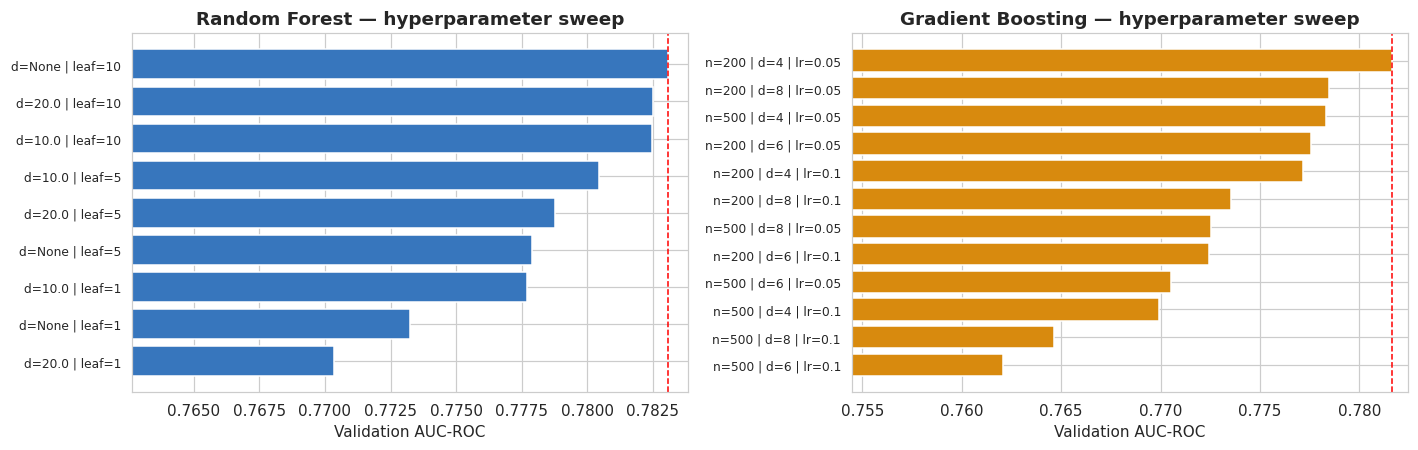

In [ ]:
# Plot the validation AUC ranking for both models
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

# RF
rf_sorted = rf_grid.sort_values("val_auc_roc", ascending=True)
labels_rf = [f"d={d if not pd.isna(d) else 'None'} | leaf={l}"
             for d, l in zip(rf_sorted["max_depth"], rf_sorted["min_samples_leaf"])]
axes[0].barh(range(len(rf_sorted)), rf_sorted["val_auc_roc"], color="#3776BD")
axes[0].set_yticks(range(len(rf_sorted)))
axes[0].set_yticklabels(labels_rf, fontsize=8)
axes[0].set_xlim(rf_sorted["val_auc_roc"].min() * 0.99,
                 rf_sorted["val_auc_roc"].max() * 1.001)
axes[0].set_xlabel("Validation AUC-ROC")
axes[0].set_title("Random Forest — hyperparameter sweep")
axes[0].axvline(rf_sorted["val_auc_roc"].max(), color="red", lw=1, ls="--")

# GBM
gbm_sorted = gbm_grid.sort_values("val_auc_roc", ascending=True)
labels_gbm = [f"n={n} | d={d} | lr={lr}"
              for n, d, lr in zip(gbm_sorted["n_estimators"],
                                  gbm_sorted["max_depth"],
                                  gbm_sorted["learning_rate"])]
axes[1].barh(range(len(gbm_sorted)), gbm_sorted["val_auc_roc"], color="#D88A0E")
axes[1].set_yticks(range(len(gbm_sorted)))
axes[1].set_yticklabels(labels_gbm, fontsize=8)
axes[1].set_xlim(gbm_sorted["val_auc_roc"].min() * 0.99,
                 gbm_sorted["val_auc_roc"].max() * 1.001)
axes[1].set_xlabel("Validation AUC-ROC")
axes[1].set_title("Gradient Boosting — hyperparameter sweep")
axes[1].axvline(gbm_sorted["val_auc_roc"].max(), color="red", lw=1, ls="--")

plt.tight_layout()
plt.show()


## 6 · Test-set performance

Computes the metrics and visualizes the **confusion matrices, ROC curves, Precision–Recall curves**, and the predicted-probability distribution.

In [ ]:
def evaluate_model(model, X_test, y_test, threshold=0.5):
    p_test = model.predict_proba(X_test)[:, 1]
    y_pred = (p_test >= threshold).astype(int)
    return {
        "auc_roc": roc_auc_score(y_test, p_test),
        "auc_pr": average_precision_score(y_test, p_test),
        "accuracy": accuracy_score(y_test, y_pred),
        "precision_default": precision_score(y_test, y_pred),
        "recall_default": recall_score(y_test, y_pred),
        "f1_default": f1_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
    }


rf_metrics  = evaluate_model(rf,  X_test, y_test)
gbm_metrics = evaluate_model(gbm, X_test, y_test)
test_metrics = pd.DataFrame({"random_forest": rf_metrics, "gradient_boosting": gbm_metrics})
test_metrics.to_csv(TABLES_DIR / "test_metrics.csv")

print("Test-set metrics — head():")
display(test_metrics.round(4).head(10))

# Cache predicted probabilities for downstream visualizations
p_test_rf  = rf.predict_proba(X_test)[:,  1]
p_test_gbm = gbm.predict_proba(X_test)[:, 1]
y_pred_rf  = (p_test_rf  >= 0.5).astype(int)
y_pred_gbm = (p_test_gbm >= 0.5).astype(int)


Test-set metrics — head():


,random_forest,gradient_boosting
auc_roc,0.7787,0.7778
auc_pr,0.5609,0.5557
accuracy,0.7927,0.7649
precision_default,0.5301,0.4754
recall_default,0.5487,0.6131
f1_default,0.5393,0.5356
balanced_accuracy,0.7053,0.7105


### 6.1 · Confusion matrix heatmaps

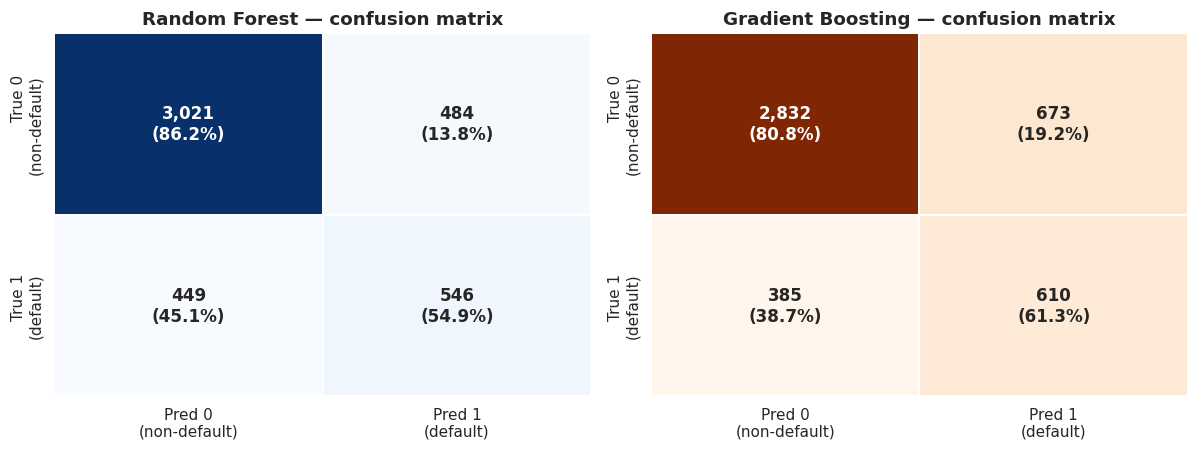

RF confusion matrix:


,pred_0,pred_1
true_0,3021,484
true_1,449,546



GBM confusion matrix:


,pred_0,pred_1
true_0,2832,673
true_1,385,610


In [ ]:
def plot_confusion(ax, cm, title, cmap="Blues"):
    """Annotated confusion matrix with row-normalized percentages."""
    cm_norm = cm / cm.sum(axis=1, keepdims=True)
    annot = np.empty_like(cm).astype(object)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            annot[i, j] = f"{cm[i,j]:,}\n({cm_norm[i,j]*100:.1f}%)"
    sns.heatmap(cm, annot=annot, fmt="", cmap=cmap, cbar=False, ax=ax,
                xticklabels=["Pred 0\n(non-default)", "Pred 1\n(default)"],
                yticklabels=["True 0\n(non-default)", "True 1\n(default)"],
                linewidths=1, linecolor="white",
                annot_kws={"fontsize": 11, "fontweight": "bold"})
    ax.set_title(title); ax.set_xlabel(""); ax.set_ylabel("")


rf_cm  = confusion_matrix(y_test, y_pred_rf)
gbm_cm = confusion_matrix(y_test, y_pred_gbm)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
plot_confusion(axes[0], rf_cm,  "Random Forest — confusion matrix",      cmap="Blues")
plot_confusion(axes[1], gbm_cm, "Gradient Boosting — confusion matrix",  cmap="Oranges")
plt.tight_layout()
plt.show()

# Save CSVs too
pd.DataFrame(rf_cm,  index=["true_0","true_1"], columns=["pred_0","pred_1"]).to_csv(
    TABLES_DIR / "confusion_random_forest.csv")
pd.DataFrame(gbm_cm, index=["true_0","true_1"], columns=["pred_0","pred_1"]).to_csv(
    TABLES_DIR / "confusion_gradient_boosting.csv")

print("RF confusion matrix:")
display(pd.DataFrame(rf_cm,  index=["true_0","true_1"], columns=["pred_0","pred_1"]).head())
print("\nGBM confusion matrix:")
display(pd.DataFrame(gbm_cm, index=["true_0","true_1"], columns=["pred_0","pred_1"]).head())


### 6.2 · ROC and Precision–Recall curves

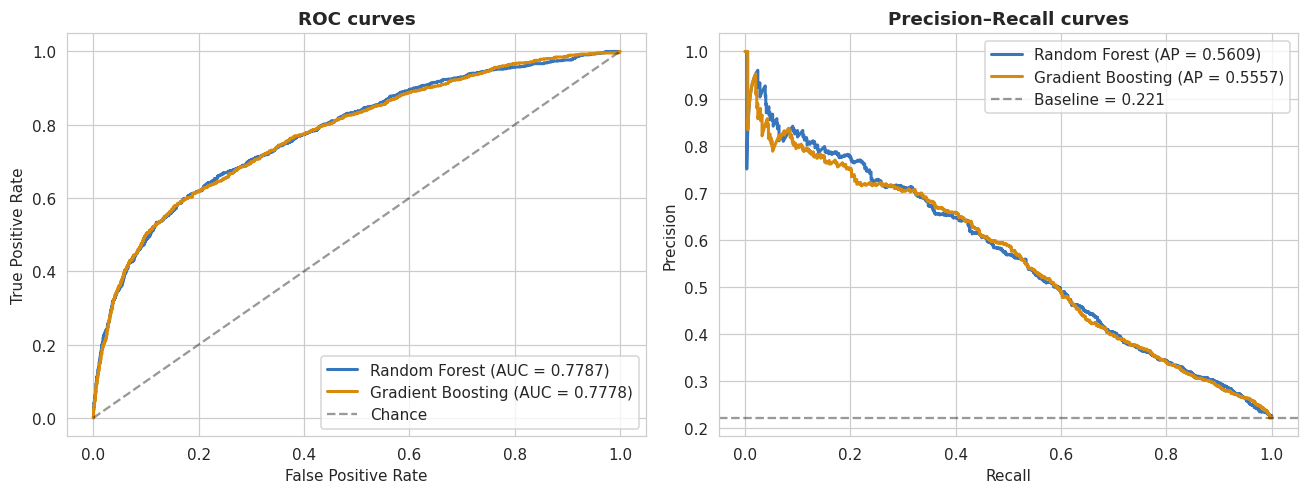

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))

# ROC
fpr_rf,  tpr_rf,  _ = roc_curve(y_test, p_test_rf)
fpr_gbm, tpr_gbm, _ = roc_curve(y_test, p_test_gbm)
axes[0].plot(fpr_rf,  tpr_rf,  label=f"Random Forest (AUC = {rf_metrics['auc_roc']:.4f})",
             color="#3776BD", lw=2)
axes[0].plot(fpr_gbm, tpr_gbm, label=f"Gradient Boosting (AUC = {gbm_metrics['auc_roc']:.4f})",
             color="#D88A0E", lw=2)
axes[0].plot([0,1],[0,1], "k--", alpha=0.4, label="Chance")
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC curves"); axes[0].legend(loc="lower right")

# PR
prec_rf,  rec_rf,  _ = precision_recall_curve(y_test, p_test_rf)
prec_gbm, rec_gbm, _ = precision_recall_curve(y_test, p_test_gbm)
axes[1].plot(rec_rf,  prec_rf,  label=f"Random Forest (AP = {rf_metrics['auc_pr']:.4f})",
             color="#3776BD", lw=2)
axes[1].plot(rec_gbm, prec_gbm, label=f"Gradient Boosting (AP = {gbm_metrics['auc_pr']:.4f})",
             color="#D88A0E", lw=2)
axes[1].axhline(y_test.mean(), color="k", ls="--", alpha=0.4,
                label=f"Baseline = {y_test.mean():.3f}")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision–Recall curves"); axes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()


### 6.3 · Distribution of predicted probabilities

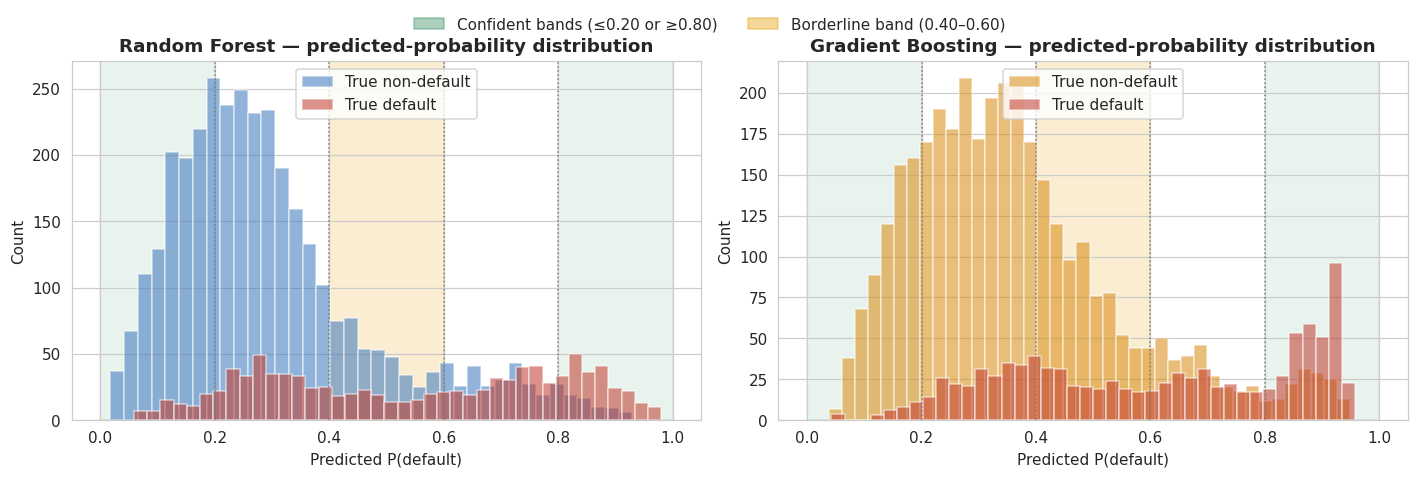

In [ ]:
# Show each model's predicted-probability distribution and mark the stratum bands
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

for ax, p, name, color in [
    (axes[0], p_test_rf,  "Random Forest",     "#3776BD"),
    (axes[1], p_test_gbm, "Gradient Boosting", "#D88A0E"),
]:
    ax.hist(p[y_test == 0], bins=40, alpha=0.55, label="True non-default", color=color)
    ax.hist(p[y_test == 1], bins=40, alpha=0.55, label="True default",     color="#C0392B")
    # Stratum bands
    ax.axvspan(0.00, CONFIDENT_LOW,  alpha=0.10, color="#2E8B57", zorder=0)
    ax.axvspan(CONFIDENT_HIGH, 1.00, alpha=0.10, color="#2E8B57", zorder=0)
    ax.axvspan(BORDERLINE_LOW, BORDERLINE_HIGH, alpha=0.18, color="#E69F00", zorder=0)
    for v in [CONFIDENT_LOW, BORDERLINE_LOW, BORDERLINE_HIGH, CONFIDENT_HIGH]:
        ax.axvline(v, color="grey", ls=":", lw=1)
    ax.set_xlabel("Predicted P(default)"); ax.set_ylabel("Count")
    ax.set_title(f"{name} — predicted-probability distribution")
    ax.legend(loc="upper center")

# Add a band-legend hand-built
band_legend = [
    mpatches.Patch(color="#2E8B57", alpha=0.4, label="Confident bands (≤0.20 or ≥0.80)"),
    mpatches.Patch(color="#E69F00", alpha=0.4, label="Borderline band (0.40–0.60)"),
]
fig.legend(handles=band_legend, loc="upper center", ncol=2,
           bbox_to_anchor=(0.5, 1.04), frameon=False, fontsize=10)
plt.tight_layout()
plt.show()


## 7 · Stratify test predictions (3 strata)

Operational definitions:

| Stratum | Confidence band | Correctness |
|---|---|---|
| Confident–Correct | p̂ ≤ 0.20 or p̂ ≥ 0.80 | Predicted class equals true label |
| Borderline | 0.40 ≤ p̂ ≤ 0.60 | Either label outcome |
| Confident–Incorrect | p̂ ≤ 0.20 or p̂ ≥ 0.80 | Predicted class differs from true label |

Predictions in the gap regions (0.20, 0.40) ∪ (0.60, 0.80) are excluded from the headline analysis.

In [ ]:
def stratify_test_set(model, X_test, y_test) -> pd.DataFrame:
    p_test = model.predict_proba(X_test)[:, 1]
    pred = (p_test >= 0.5).astype(int)
    correct = (pred == y_test)
    confident  = (p_test <= CONFIDENT_LOW) | (p_test >= CONFIDENT_HIGH)
    borderline = (p_test >= BORDERLINE_LOW) & (p_test <= BORDERLINE_HIGH)
    stratum = np.full(len(y_test), "other", dtype=object)
    stratum[confident & correct]    = "confident_correct"
    stratum[confident & (~correct)] = "confident_incorrect"
    stratum[borderline]             = "borderline"
    return pd.DataFrame({
        "test_idx": np.arange(len(y_test)),
        "p_default": p_test, "predicted": pred, "true": y_test,
        "correct": correct, "stratum": stratum,
    })


def sample_per_stratum(strata_df, n_per_stratum=INSTANCES_PER_STRATUM, seed=SEED):
    rng = np.random.RandomState(seed)
    out = {}
    for s in STRATUM_ORDER:
        idx = strata_df.index[strata_df["stratum"] == s].tolist()
        if len(idx) > n_per_stratum:
            idx = rng.choice(idx, size=n_per_stratum, replace=False).tolist()
        out[s] = sorted(idx)
    return out


strata_rf  = stratify_test_set(rf,  X_test, y_test)
strata_gbm = stratify_test_set(gbm, X_test, y_test)
counts = pd.DataFrame({
    "random_forest":     strata_rf["stratum"].value_counts(),
    "gradient_boosting": strata_gbm["stratum"].value_counts(),
}).fillna(0).astype(int)
counts = counts.reindex(STRATUM_ORDER + ["other"])
counts.to_csv(TABLES_DIR / "stratum_counts.csv")

print("Stratum counts (test set) — head():")
display(counts.head())

print("\nRF strata dataframe — head():")
display(strata_rf.head())
print("\nGBM strata dataframe — head():")
display(strata_gbm.head())

sample_rf  = sample_per_stratum(strata_rf)
sample_gbm = sample_per_stratum(strata_gbm)
print("\nSampled per stratum (RF):",  {k: len(v) for k, v in sample_rf.items()})
print("Sampled per stratum (GBM):", {k: len(v) for k, v in sample_gbm.items()})


Stratum counts (test set) — head():


,random_forest,gradient_boosting
stratum,,
confident_correct,1341,985
borderline,575,971
confident_incorrect,145,173
other,2439,2371



RF strata dataframe — head():


,test_idx,p_default,predicted,true,correct,stratum
0,0,0.978642,1,1,True,confident_correct
1,1,0.234386,0,1,False,other
2,2,0.249669,0,0,True,other
3,3,0.120408,0,0,True,confident_correct
4,4,0.304142,0,0,True,other



GBM strata dataframe — head():


,test_idx,p_default,predicted,true,correct,stratum
0,0,0.952774,1,1,True,confident_correct
1,1,0.263209,0,1,False,other
2,2,0.267637,0,0,True,other
3,3,0.169064,0,0,True,confident_correct
4,4,0.310585,0,0,True,other



Sampled per stratum (RF): {'confident_correct': 100, 'borderline': 100, 'confident_incorrect': 100}
Sampled per stratum (GBM): {'confident_correct': 100, 'borderline': 100, 'confident_incorrect': 100}


### 7.1 · Visualize the stratification

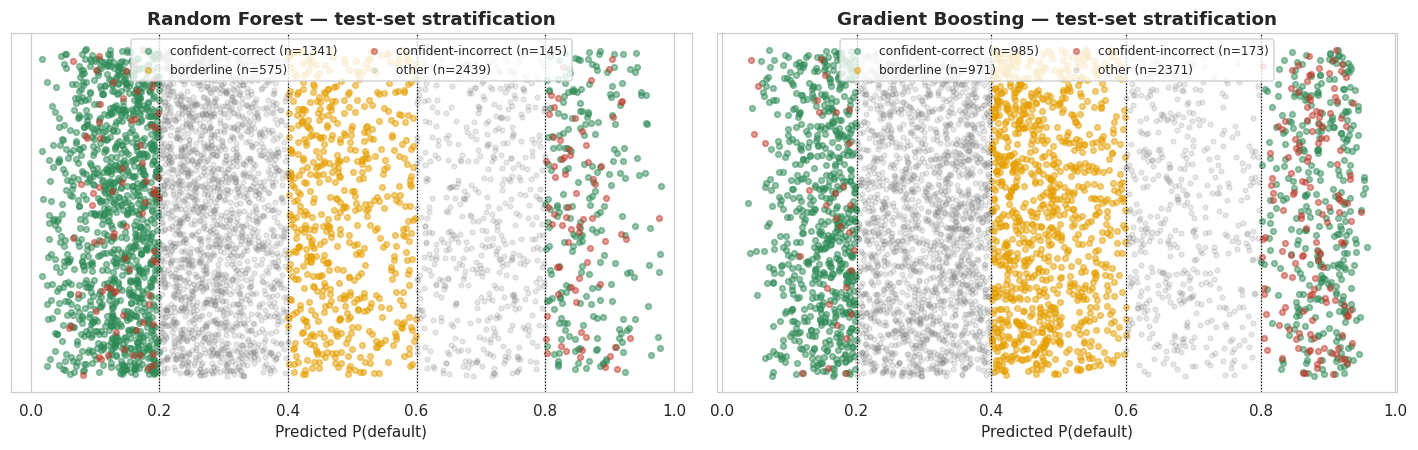

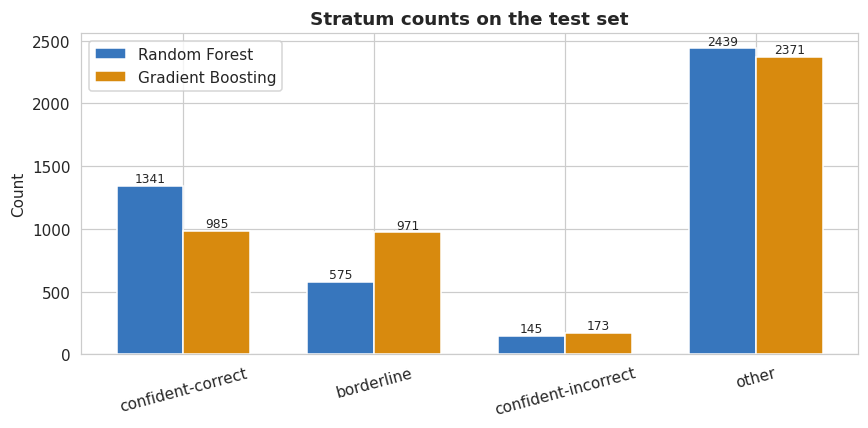

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

for ax, strata_df, name in [
    (axes[0], strata_rf,  "Random Forest"),
    (axes[1], strata_gbm, "Gradient Boosting"),
]:
    for s in STRATUM_ORDER:
        sub = strata_df[strata_df["stratum"] == s]
        ax.scatter(sub["p_default"], np.random.uniform(0, 1, size=len(sub)),
                   alpha=0.5, s=14, color=STRATUM_COLORS[s],
                   label=f"{s.replace('_', '-')} (n={len(sub)})")
    other = strata_df[strata_df["stratum"] == "other"]
    ax.scatter(other["p_default"], np.random.uniform(0, 1, size=len(other)),
               alpha=0.18, s=10, color="grey", label=f"other (n={len(other)})")
    for v in [CONFIDENT_LOW, BORDERLINE_LOW, BORDERLINE_HIGH, CONFIDENT_HIGH]:
        ax.axvline(v, color="black", ls=":", lw=0.8)
    ax.set_xlabel("Predicted P(default)")
    ax.set_yticks([])
    ax.set_title(f"{name} — test-set stratification")
    ax.legend(loc="upper center", fontsize=8, ncol=2)

plt.tight_layout()
plt.show()

# Stratum-count bar chart
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(counts.index)); w = 0.35
ax.bar(x - w/2, counts["random_forest"],     width=w, label="Random Forest",     color="#3776BD")
ax.bar(x + w/2, counts["gradient_boosting"], width=w, label="Gradient Boosting", color="#D88A0E")
for i, (rf_v, gb_v) in enumerate(zip(counts["random_forest"], counts["gradient_boosting"])):
    ax.text(i - w/2, rf_v + 30, str(rf_v), ha="center", fontsize=8)
    ax.text(i + w/2, gb_v + 30, str(gb_v), ha="center", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([s.replace("_","-") for s in counts.index], rotation=15)
ax.set_ylabel("Count"); ax.set_title("Stratum counts on the test set")
ax.legend()
plt.tight_layout()
plt.show()


## 8 · Stability and agreement metrics

Two headline metrics from Methodology Section III-E.3.

In [ ]:
def spearman_rho(a, b):
    a, b = np.asarray(a, dtype=float), np.asarray(b, dtype=float)
    if np.std(a) < 1e-12 or np.std(b) < 1e-12:
        return np.nan
    rho, _ = sp_stats.spearmanr(a, b)
    return float(rho) if not np.isnan(rho) else np.nan


def top_k_jaccard(a, b, k=5):
    a, b = np.abs(np.asarray(a)), np.abs(np.asarray(b))
    top_a = set(np.argsort(a)[-k:].tolist())
    top_b = set(np.argsort(b)[-k:].tolist())
    union = top_a | top_b
    return len(top_a & top_b) / len(union) if union else np.nan


## 9 · Type-aware perturber

Continuous: additive Gaussian σ × std(j). Ordinal: ±1 shift with probability 0.20, clipped to training range. Categorical: held fixed.

In [ ]:
class TypeAwarePerturber:
    def __init__(self, X_train, sigma=PERTURB_SIGMA_HEADLINE,
                 ordinal_shift_prob=ORDINAL_SHIFT_PROB, seed=SEED):
        self.sigma = sigma
        self.ordinal_shift_prob = ordinal_shift_prob
        self.feat_names = list(X_train.columns)
        self.continuous = [f for f in CONTINUOUS_FEATURES if f in self.feat_names]
        self.ordinal    = [f for f in ORDINAL_FEATURES    if f in self.feat_names]
        self.cont_std = X_train[self.continuous].std().to_dict()
        self.ord_min  = X_train[self.ordinal].min().to_dict()
        self.ord_max  = X_train[self.ordinal].max().to_dict()
        self.rng = np.random.RandomState(seed)

    def perturb(self, x: pd.Series, n: int) -> pd.DataFrame:
        rows = []
        for _ in range(n):
            xp = x.astype(float).copy()
            for f in self.continuous:
                xp[f] = xp[f] + self.rng.normal(0, self.sigma * self.cont_std[f])
            for f in self.ordinal:
                if self.rng.rand() < self.ordinal_shift_prob:
                    shift = self.rng.choice([-1, 1])
                    xp[f] = float(np.clip(xp[f] + shift, self.ord_min[f], self.ord_max[f]))
            rows.append(xp)
        return pd.DataFrame(rows).reset_index(drop=True)


## 10 · Explainers — TreeSHAP and LIME

Build SHAP and LIME explainers per model. Each per-instance attribution is a 1-D vector of length p (one weight per feature).

In [ ]:
def build_explainers(model, X_train):
    from lime.lime_tabular import LimeTabularExplainer
    try:
        shap_expl = shap.TreeExplainer(model)
    except Exception as e:
        print(f"TreeExplainer init failed ({e}); using generic Explainer.")
        shap_expl = shap.Explainer(model.predict_proba, X_train.iloc[:200])
    feat_names = list(X_train.columns)
    cat_idx = [feat_names.index(f) for f in CATEGORICAL_FEATURES if f in feat_names]
    lime_expl = LimeTabularExplainer(
        training_data=X_train.values,
        feature_names=feat_names,
        class_names=["non_default", "default"],
        categorical_features=cat_idx,
        discretize_continuous=False,
        random_state=SEED,
    )
    return shap_expl, lime_expl


def shap_attribution(shap_expl, x_row: pd.Series) -> np.ndarray:
    arr = np.asarray(x_row.values).reshape(1, -1)
    sv = shap_expl(arr) if callable(shap_expl) else shap_expl.shap_values(arr)
    if hasattr(sv, "values"):
        v = sv.values
        if   v.ndim == 3: v = v[0, :, 1]
        elif v.ndim == 2: v = v[0]
        else:             v = v.flatten()
    elif isinstance(sv, list):
        v = np.asarray(sv[1]).flatten() if len(sv) > 1 else np.asarray(sv[0]).flatten()
    else:
        v = np.asarray(sv).flatten()
    return v


def lime_attribution(lime_expl, model, x_row: pd.Series, n_features: int) -> np.ndarray:
    expl = lime_expl.explain_instance(
        data_row=x_row.values,
        predict_fn=model.predict_proba,
        num_features=n_features,
        num_samples=LIME_NUM_SAMPLES,
        labels=[1],
    )
    weights = np.zeros(n_features)
    for fid, w in expl.as_map()[1]:
        weights[fid] = w
    return weights


# Build the explainers once, reused everywhere
shap_rf,  lime_rf  = build_explainers(rf,  X_train)
shap_gbm, lime_gbm = build_explainers(gbm, X_train)
print("Built TreeSHAP + LIME explainers for both models.")


Built TreeSHAP + LIME explainers for both models.


### 10.1 · Global SHAP beeswarm — like the reference figure

This is the **summary plot** every SHAP-based paper shows: every dot is one test instance, x-axis is the SHAP value (impact on the model's predicted log-odds of default), color is the feature value (red=high, blue=low). Features sorted by mean absolute SHAP value.

Random Forest — TreeSHAP beeswarm summary (top-20 features)


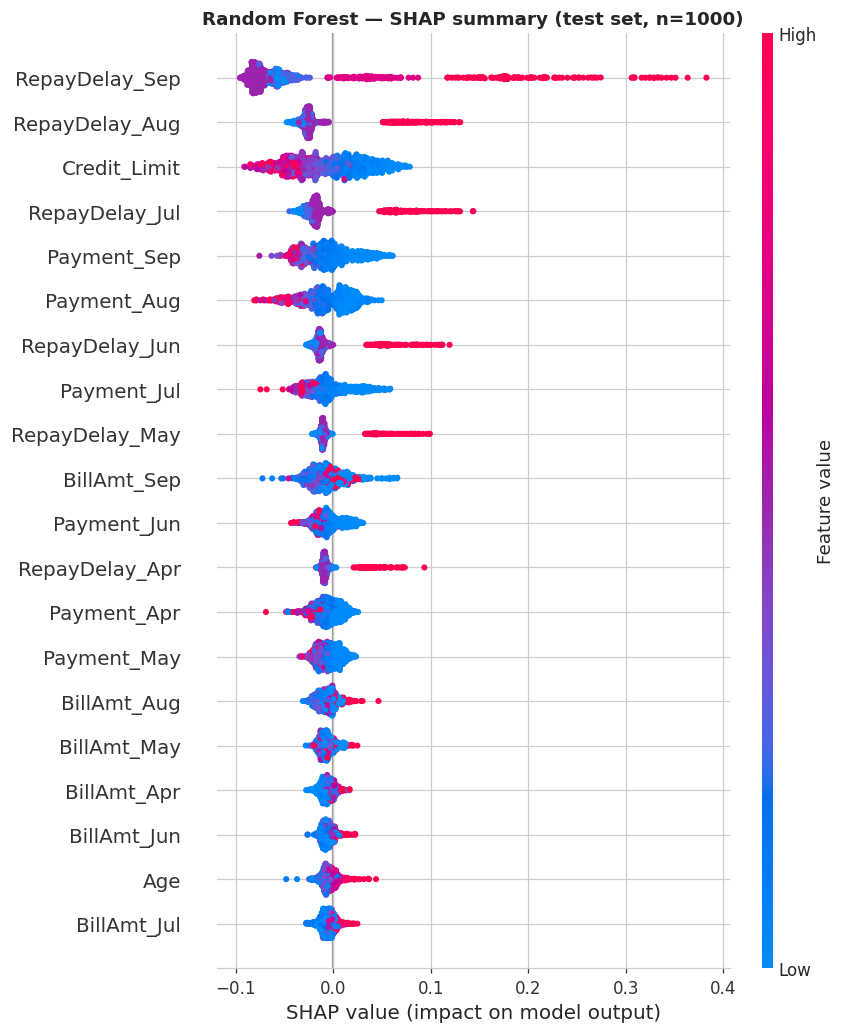


Gradient Boosting — TreeSHAP beeswarm summary (top-20 features)


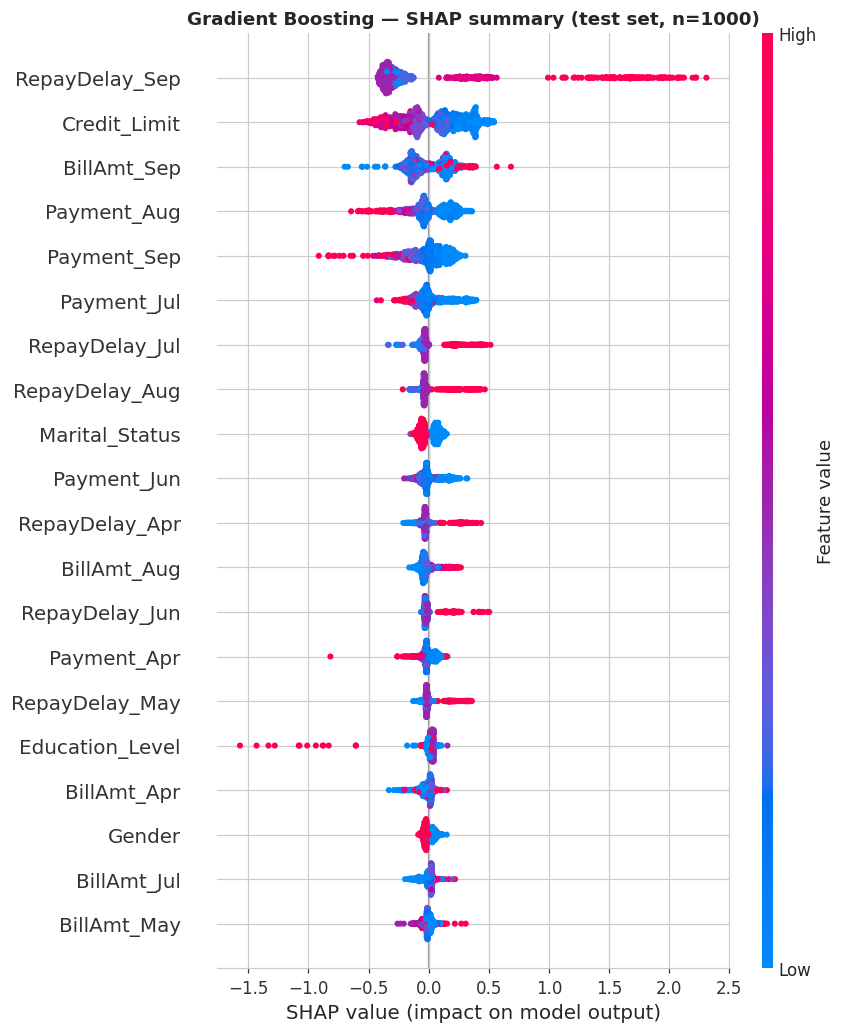


Mean |SHAP value| — bar version (Random Forest)


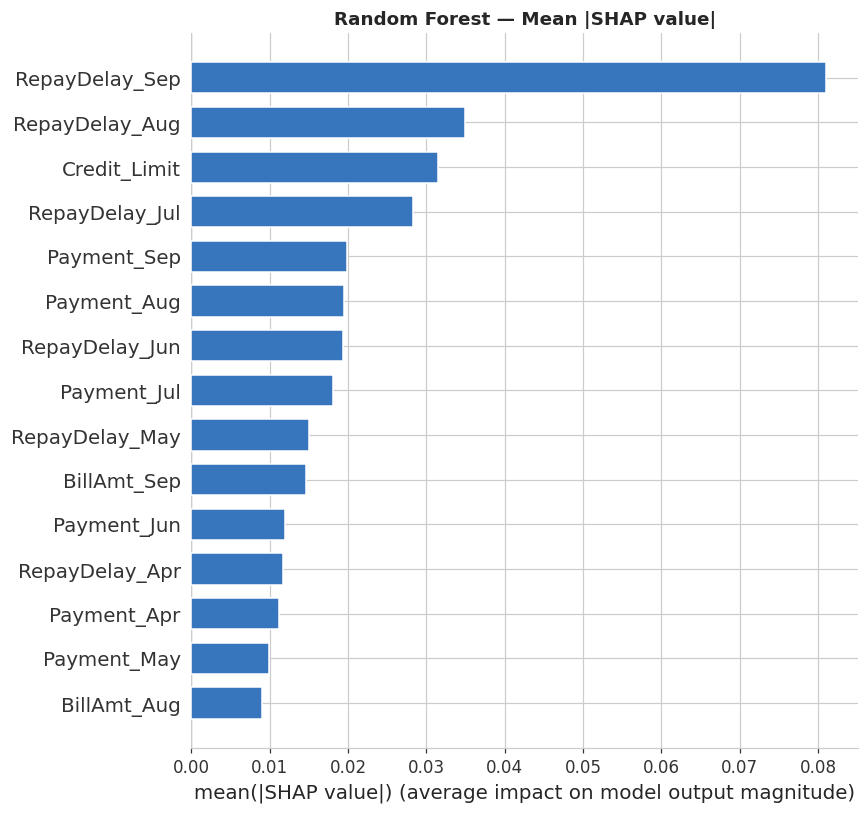

In [ ]:
def compute_shap_values_batch(model, X_sample, model_name=""):
    """Return a numpy array of shape (n, p) of SHAP values for the positive class."""
    expl = shap.TreeExplainer(model)
    sv = expl(X_sample)
    v = sv.values
    if v.ndim == 3:
        v = v[:, :, 1]
    return v, sv


# Use a 1000-row sample of the test set for the beeswarm (keeps it fast, looks right)
n_sample = min(1000, len(X_test))
X_sample = X_test.iloc[:n_sample]

shap_vals_rf,  shap_obj_rf  = compute_shap_values_batch(rf,  X_sample, "Random Forest")
shap_vals_gbm, shap_obj_gbm = compute_shap_values_batch(gbm, X_sample, "Gradient Boosting")

# Random Forest beeswarm
print("Random Forest — TreeSHAP beeswarm summary (top-20 features)")
plt.figure(figsize=(9, 7))
shap.summary_plot(shap_vals_rf, X_sample, plot_type="dot",
                  max_display=20, show=False)
plt.title("Random Forest — SHAP summary (test set, n=" + str(n_sample) + ")",
          fontsize=12, weight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "shap_beeswarm_rf.png", bbox_inches="tight")
plt.show()

# Gradient Boosting beeswarm
print("\nGradient Boosting — TreeSHAP beeswarm summary (top-20 features)")
plt.figure(figsize=(9, 7))
shap.summary_plot(shap_vals_gbm, X_sample, plot_type="dot",
                  max_display=20, show=False)
plt.title("Gradient Boosting — SHAP summary (test set, n=" + str(n_sample) + ")",
          fontsize=12, weight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "shap_beeswarm_gbm.png", bbox_inches="tight")
plt.show()

# Bar version (mean |SHAP|) — companion view
print("\nMean |SHAP value| — bar version (Random Forest)")
plt.figure(figsize=(9, 6))
shap.summary_plot(shap_vals_rf, X_sample, plot_type="bar",
                  max_display=15, show=False, color="#3776BD")
plt.title("Random Forest — Mean |SHAP value|", fontsize=12, weight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "shap_bar_rf.png", bbox_inches="tight")
plt.show()


### 10.2 · Per-instance SHAP **before vs. after perturbation**

Experiment A measures: pick one instance from each stratum, compute SHAP on the original input, then compute SHAP on a single σ=0.03 perturbation of the same instance, and show both side-by-side. If the explanation is stable, the two bars should look almost identical. If it is unstable, you'll see feature rankings flip between the two views.

=== Random Forest — before/after perturbation demo ===


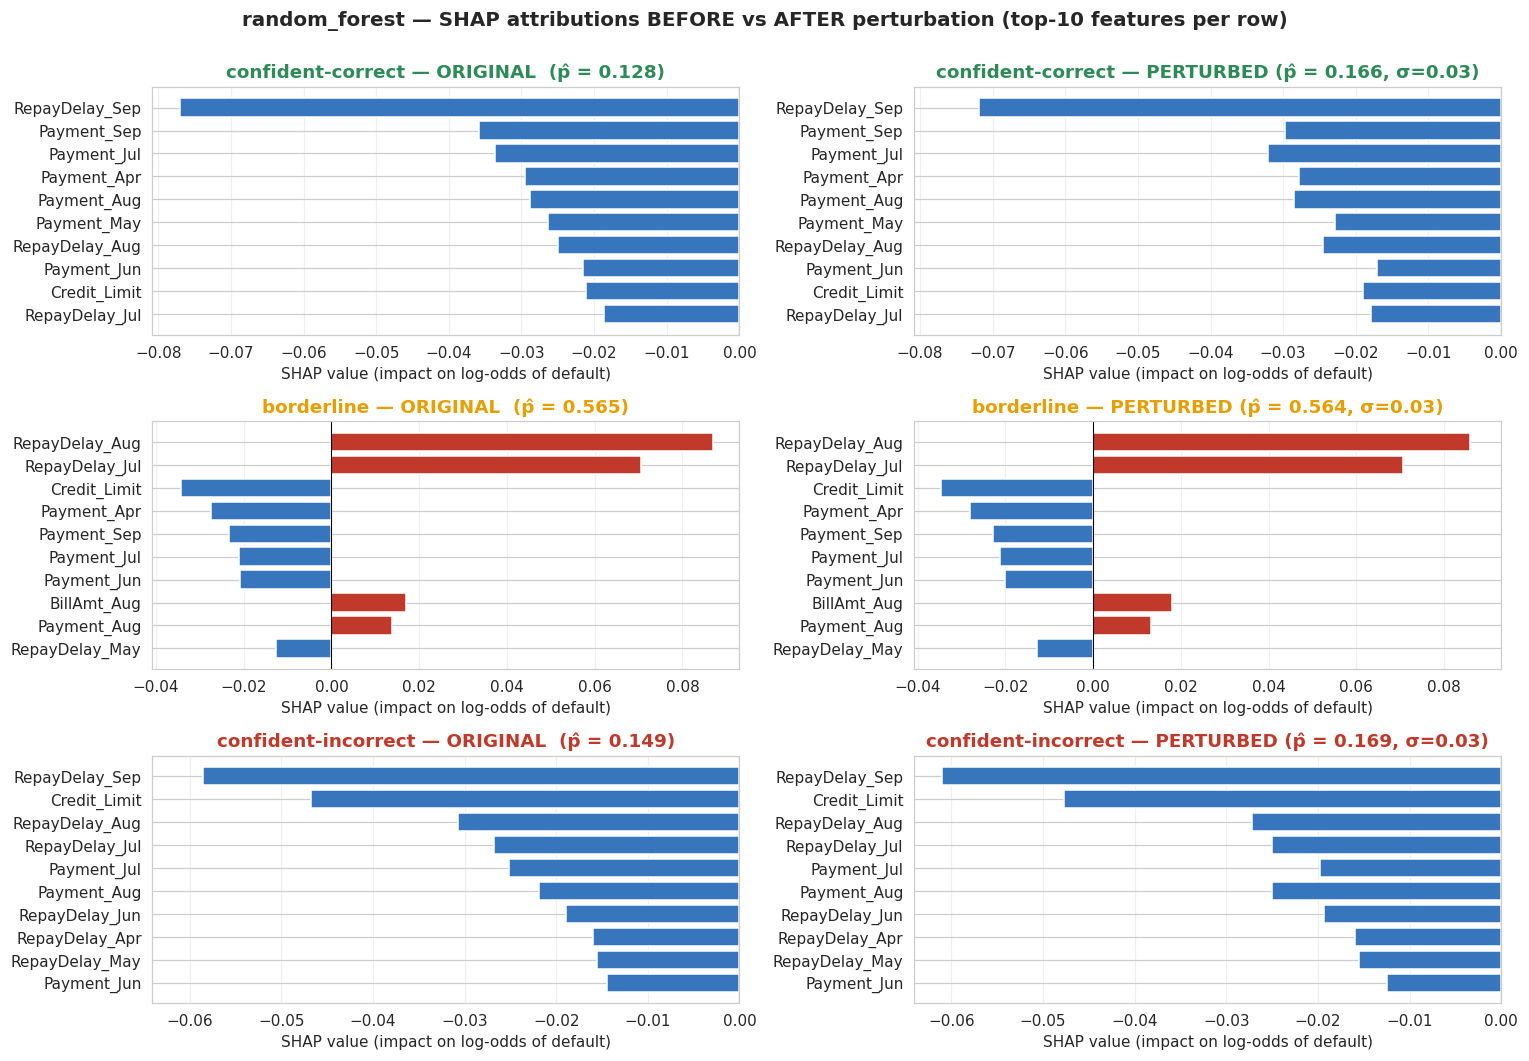

,stratum,test_idx,p_orig,p_perturbed,spearman_rho,top5_jaccard
0,confident_correct,2674,0.1285,0.1663,0.9713,1.0000
1,borderline,4459,0.5655,0.5637,1.0000,1.0000
2,confident_incorrect,952,0.1489,0.1690,0.9733,0.6667



=== Gradient Boosting — before/after perturbation demo ===


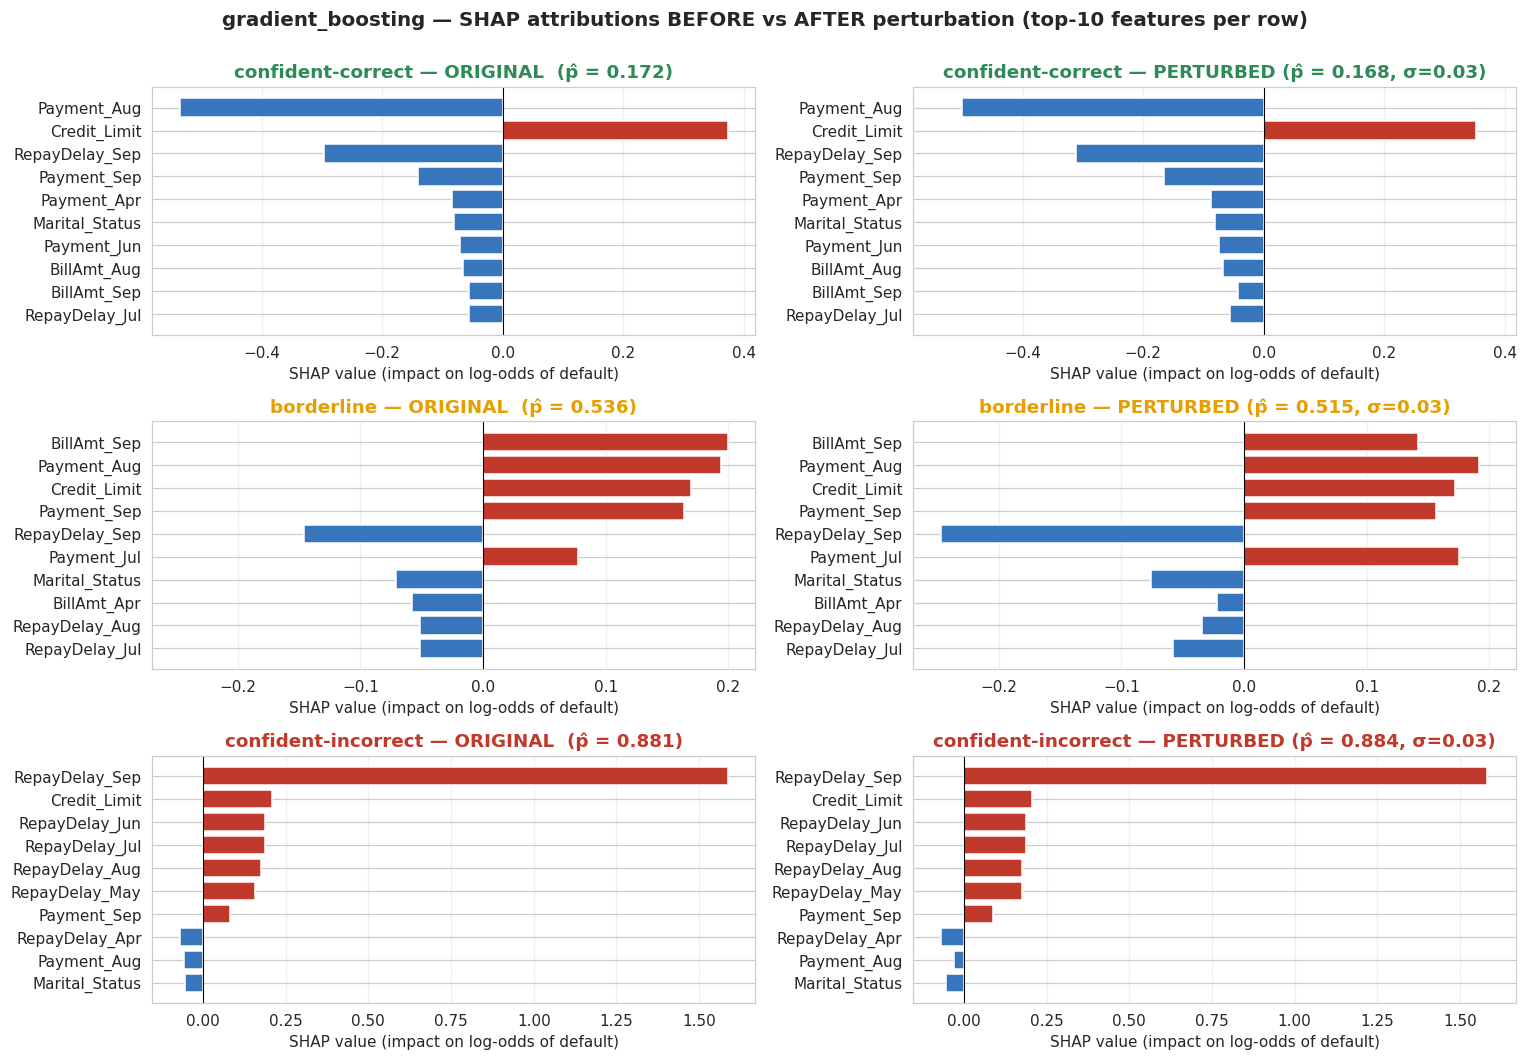

,stratum,test_idx,p_orig,p_perturbed,spearman_rho,top5_jaccard
0,confident_correct,2756,0.1719,0.1684,0.9941,1.0000
1,borderline,2082,0.5364,0.5148,0.8725,0.6667
2,confident_incorrect,605,0.8808,0.8839,0.9773,0.6667


In [ ]:
def pick_demo_instances(strata_df, n=1, seed=SEED):
    """Pick one instance index per stratum for the demo."""
    rng = np.random.RandomState(seed)
    picks = {}
    for s in STRATUM_ORDER:
        idx = strata_df.index[strata_df["stratum"] == s].tolist()
        if len(idx) >= n:
            picks[s] = rng.choice(idx, size=n, replace=False).tolist()
        else:
            picks[s] = idx
    return picks


def shap_before_after_perturb(model, model_name, shap_expl, X_test, X_train,
                              strata_df, sigma=PERTURB_SIGMA_HEADLINE,
                              top_k=10):
    """For each stratum, pick one instance and visualize SHAP before vs after a single perturbation."""
    picks = pick_demo_instances(strata_df, n=1)
    perturber = TypeAwarePerturber(X_train, sigma=sigma, seed=SEED + 1)

    fig, axes = plt.subplots(len(STRATUM_ORDER), 2,
                             figsize=(14, 3.2 * len(STRATUM_ORDER)),
                             sharex="row")
    feature_names = list(X_test.columns)

    rows_summary = []
    for row_i, stratum in enumerate(STRATUM_ORDER):
        if not picks[stratum]:
            for j in range(2):
                axes[row_i, j].text(0.5, 0.5, f"No samples in {stratum}",
                                    ha="center", va="center",
                                    transform=axes[row_i, j].transAxes)
                axes[row_i, j].set_axis_off()
            continue
        idx = picks[stratum][0]
        x = X_test.iloc[idx]
        # Original SHAP
        phi_0 = shap_attribution(shap_expl, x)
        p_0 = float(model.predict_proba(x.values.reshape(1,-1))[0, 1])

        # Perturbed SHAP (single neighbor that survives the prediction-stability filter, if possible)
        phi_p = None; p_p = None
        for _ in range(20):
            x_p = perturber.perturb(x, 1).iloc[0]
            p_p_try = float(model.predict_proba(x_p.values.reshape(1,-1))[0, 1])
            if abs(p_p_try - p_0) < PRED_STABILITY_FILTER:
                phi_p = shap_attribution(shap_expl, x_p)
                p_p = p_p_try
                break
        if phi_p is None:
            x_p = perturber.perturb(x, 1).iloc[0]
            phi_p = shap_attribution(shap_expl, x_p)
            p_p = float(model.predict_proba(x_p.values.reshape(1,-1))[0, 1])

        # Sort features by |original SHAP| descending, show top_k
        order = np.argsort(np.abs(phi_0))[::-1][:top_k]
        feats = [feature_names[i] for i in order][::-1]
        v_0 = phi_0[order][::-1]
        v_p = phi_p[order][::-1]

        # Bar plots
        colors_0 = ["#C0392B" if v > 0 else "#3776BD" for v in v_0]
        colors_p = ["#C0392B" if v > 0 else "#3776BD" for v in v_p]
        ax_a, ax_b = axes[row_i, 0], axes[row_i, 1]
        ax_a.barh(feats, v_0, color=colors_0)
        ax_b.barh(feats, v_p, color=colors_p)
        ax_a.set_title(f"{stratum.replace('_','-')} — ORIGINAL  (p̂ = {p_0:.3f})",
                       color=STRATUM_COLORS[stratum])
        ax_b.set_title(f"{stratum.replace('_','-')} — PERTURBED (p̂ = {p_p:.3f}, σ={sigma})",
                       color=STRATUM_COLORS[stratum])
        for ax in (ax_a, ax_b):
            ax.axvline(0, color="black", lw=0.7)
            ax.set_xlabel("SHAP value (impact on log-odds of default)")
            ax.grid(True, axis="x", alpha=0.3)

        rho  = spearman_rho(phi_0, phi_p)
        jacc = top_k_jaccard(phi_0, phi_p, k=5)
        rows_summary.append({"stratum": stratum, "test_idx": idx,
                             "p_orig": p_0, "p_perturbed": p_p,
                             "spearman_rho": rho, "top5_jaccard": jacc})

    fig.suptitle(f"{model_name} — SHAP attributions BEFORE vs AFTER perturbation "
                 f"(top-{top_k} features per row)", fontsize=13, weight="bold", y=1.00)
    plt.tight_layout()
    out = FIGURES_DIR / f"shap_before_after_{model_name}.png"
    plt.savefig(out, bbox_inches="tight")
    plt.show()
    return pd.DataFrame(rows_summary)


print("=== Random Forest — before/after perturbation demo ===")
demo_rf = shap_before_after_perturb(rf, "random_forest", shap_rf, X_test, X_train, strata_rf)
display(demo_rf.round(4))

print("\n=== Gradient Boosting — before/after perturbation demo ===")
demo_gbm = shap_before_after_perturb(gbm, "gradient_boosting", shap_gbm, X_test, X_train, strata_gbm)
display(demo_gbm.round(4))

demo_rf.to_csv(TABLES_DIR  / "shap_before_after_rf.csv",  index=False)
demo_gbm.to_csv(TABLES_DIR / "shap_before_after_gbm.csv", index=False)


### 10.3 · SHAP beeswarm — confident-correct vs. borderline samples

This contrasts the **distribution of SHAP attributions** across two strata. If borderline explanations are noisier, their swarms should look more diffuse and less monotone in color.

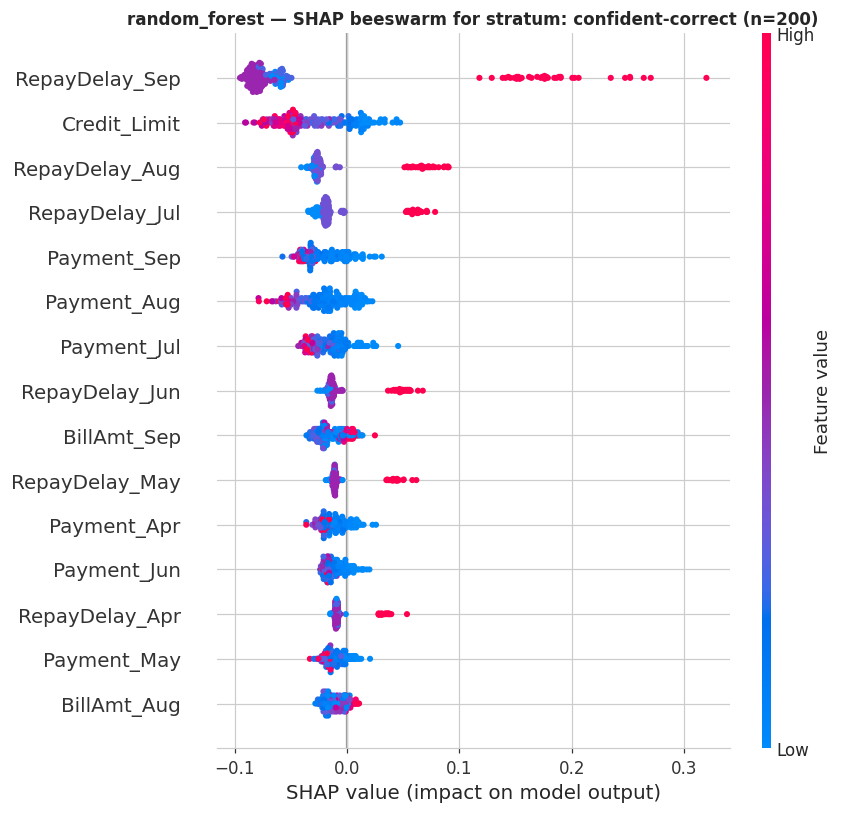

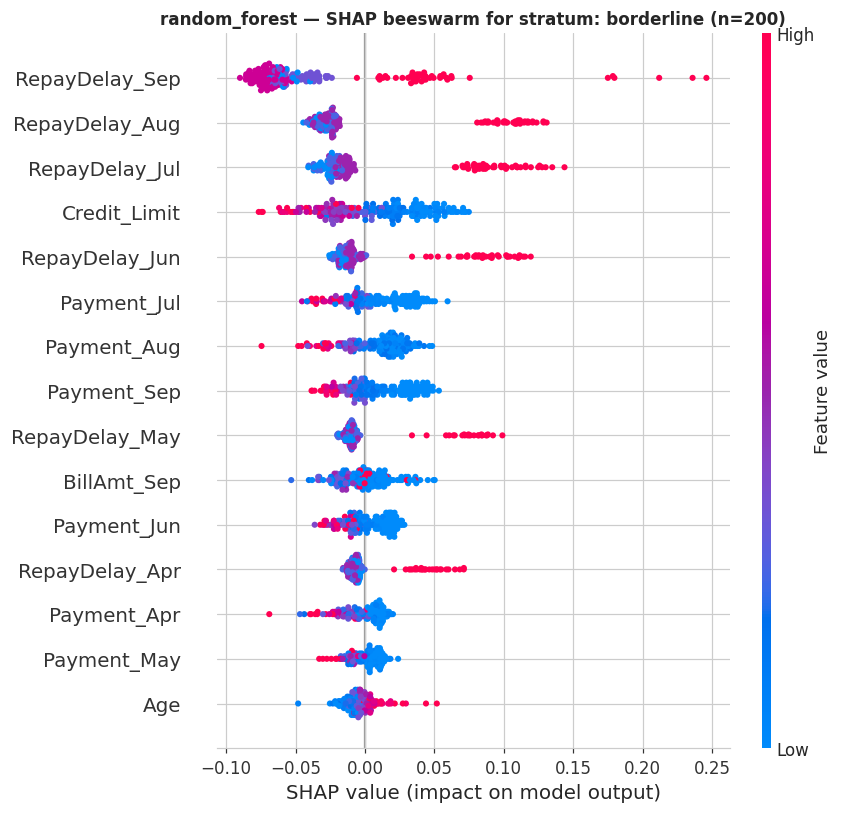

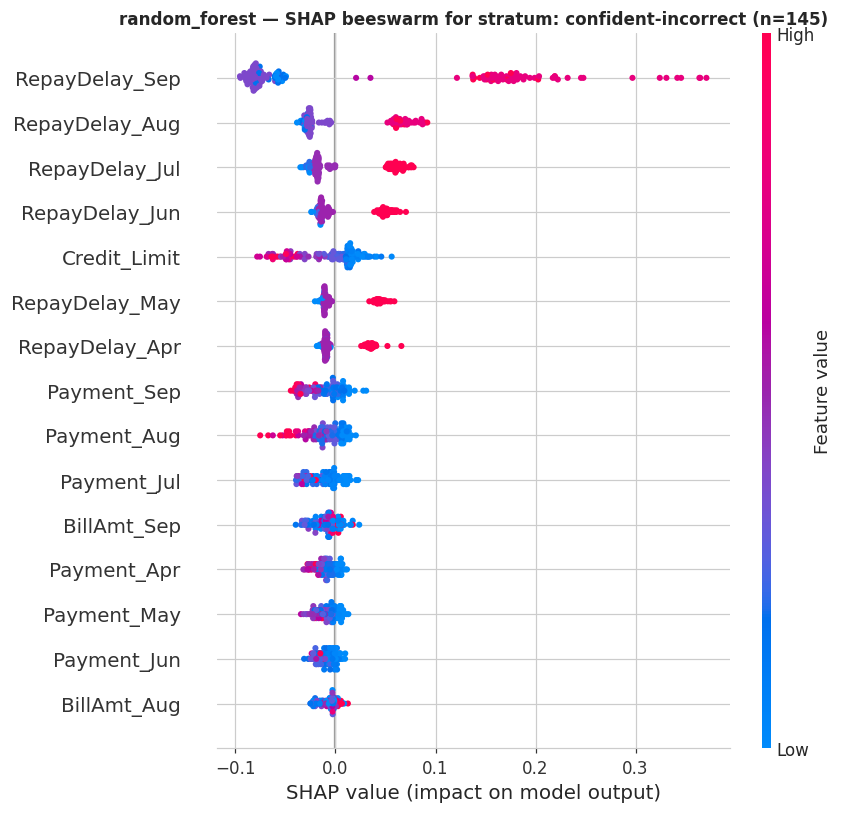

In [ ]:
def beeswarm_for_stratum(model, model_name, X_test, strata_df, stratum_label, max_n=200):
    idxs = strata_df.index[strata_df["stratum"] == stratum_label].tolist()[:max_n]
    if len(idxs) == 0:
        print(f"No samples in {stratum_label}; skipping.")
        return
    X_sub = X_test.iloc[idxs]
    expl = shap.TreeExplainer(model)
    sv = expl(X_sub)
    v = sv.values
    if v.ndim == 3:
        v = v[:, :, 1]
    plt.figure(figsize=(8.5, 6))
    shap.summary_plot(v, X_sub, plot_type="dot", max_display=15, show=False)
    plt.title(f"{model_name} — SHAP beeswarm for stratum: {stratum_label.replace('_','-')} "
              f"(n={len(idxs)})", fontsize=11, weight="bold")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"shap_beeswarm_{model_name}_{stratum_label}.png", bbox_inches="tight")
    plt.show()


for stratum in STRATUM_ORDER:
    beeswarm_for_stratum(rf, "random_forest", X_test, strata_rf, stratum)


## 11 · Experiment A — Input perturbation stability

For each instance:
1. Generate 30 type-aware neighbors at σ = 0.03.
2. Keep only neighbors with **|Δp̂| < 0.05** (the prediction-stability filter — this isolates explanation change from prediction change).
3. Compute SHAP and LIME attributions on the original instance and each surviving neighbor.
4. Report the per-instance median Spearman ρ and median Top-5 Jaccard for both methods.

In [ ]:
def run_experiment_A(model, model_name, X_test, X_train, sample, perturber,
                     pred_filter=PRED_STABILITY_FILTER, sigma_label="0.03"):
    shap_expl, lime_expl = build_explainers(model, X_train)
    rows = []
    n_feat = X_test.shape[1]
    for stratum, idx_list in sample.items():
        print(f"  [Exp A · {model_name} · σ={sigma_label}] {stratum}: {len(idx_list)} instances")
        for idx in idx_list:
            x = X_test.iloc[idx]
            p_orig = model.predict_proba(x.values.reshape(1, -1))[0, 1]
            phi_shap_0 = shap_attribution(shap_expl, x)
            phi_lime_0 = lime_attribution(lime_expl, model, x, n_feat)
            neighbors = perturber.perturb(x, N_PERTURBATIONS)
            p_neigh = model.predict_proba(neighbors.values)[:, 1]
            keep = np.abs(p_neigh - p_orig) < pred_filter
            kept = neighbors.loc[keep].reset_index(drop=True)
            shap_rhos, shap_jaccs, lime_rhos, lime_jaccs = [], [], [], []
            for _, n_row in kept.iterrows():
                phi_shap_n = shap_attribution(shap_expl, n_row)
                phi_lime_n = lime_attribution(lime_expl, model, n_row, n_feat)
                shap_rhos.append( spearman_rho(phi_shap_0, phi_shap_n))
                shap_jaccs.append(top_k_jaccard(phi_shap_0, phi_shap_n, k=5))
                lime_rhos.append( spearman_rho(phi_lime_0, phi_lime_n))
                lime_jaccs.append(top_k_jaccard(phi_lime_0, phi_lime_n, k=5))
            rows.append({
                "model": model_name, "stratum": stratum, "test_idx": idx,
                "p_orig": float(p_orig), "n_kept": int(keep.sum()),
                "shap_med_rho":  float(np.nanmedian(shap_rhos))  if shap_rhos else np.nan,
                "shap_med_jacc": float(np.nanmedian(shap_jaccs)) if shap_jaccs else np.nan,
                "lime_med_rho":  float(np.nanmedian(lime_rhos))  if lime_rhos else np.nan,
                "lime_med_jacc": float(np.nanmedian(lime_jaccs)) if lime_jaccs else np.nan,
            })
    return pd.DataFrame(rows)


# Headline σ = 0.03
perturber = TypeAwarePerturber(X_train, sigma=PERTURB_SIGMA_HEADLINE)
expA_rf  = run_experiment_A(rf,  "random_forest",     X_test, X_train, sample_rf,  perturber)
expA_gbm = run_experiment_A(gbm, "gradient_boosting", X_test, X_train, sample_gbm, perturber)
expA_rf.to_csv(TABLES_DIR  / "expA_random_forest_per_instance.csv",     index=False)
expA_gbm.to_csv(TABLES_DIR / "expA_gradient_boosting_per_instance.csv", index=False)

print("\nExp A · Random Forest — per-instance dataframe head():")
display(expA_rf.head())
print("\nExp A · Gradient Boosting — per-instance dataframe head():")
display(expA_gbm.head())

print("\nRF medians by stratum:")
display(expA_rf.groupby("stratum")[["shap_med_rho","shap_med_jacc","lime_med_rho","lime_med_jacc"]]
        .median().reindex(STRATUM_ORDER).round(3))
print("\nGBM medians by stratum:")
display(expA_gbm.groupby("stratum")[["shap_med_rho","shap_med_jacc","lime_med_rho","lime_med_jacc"]]
        .median().reindex(STRATUM_ORDER).round(3))


  [Exp A · random_forest · σ=0.03] confident_correct: 100 instances
  [Exp A · random_forest · σ=0.03] borderline: 100 instances
  [Exp A · random_forest · σ=0.03] confident_incorrect: 100 instances
  [Exp A · gradient_boosting · σ=0.03] confident_correct: 100 instances
  [Exp A · gradient_boosting · σ=0.03] borderline: 100 instances
  [Exp A · gradient_boosting · σ=0.03] confident_incorrect: 100 instances

Exp A · Random Forest — per-instance dataframe head():


,model,stratum,test_idx,p_orig,n_kept,shap_med_rho,shap_med_jacc,lime_med_rho,lime_med_jacc
0,random_forest,confident_correct,93,0.145980,28,0.944664,0.666667,0.973814,1.000000
1,random_forest,confident_correct,141,0.041309,27,0.984190,1.000000,0.974308,1.000000
2,random_forest,confident_correct,155,0.874137,24,0.978261,1.000000,0.970356,0.666667
3,random_forest,confident_correct,169,0.871764,27,0.988142,1.000000,0.951581,1.000000
4,random_forest,confident_correct,207,0.037869,29,0.992095,1.000000,0.965415,1.000000



Exp A · Gradient Boosting — per-instance dataframe head():


,model,stratum,test_idx,p_orig,n_kept,shap_med_rho,shap_med_jacc,lime_med_rho,lime_med_jacc
0,gradient_boosting,confident_correct,94,0.127196,20,0.992589,1.000000,0.975296,1.000000
1,gradient_boosting,confident_correct,117,0.088868,28,0.989130,0.666667,0.981719,0.666667
2,gradient_boosting,confident_correct,163,0.918479,24,0.995059,0.666667,0.981719,1.000000
3,gradient_boosting,confident_correct,273,0.069609,30,0.986660,1.000000,0.977273,0.666667
4,gradient_boosting,confident_correct,289,0.868676,24,0.925395,0.833333,0.984190,1.000000



RF medians by stratum:


,shap_med_rho,shap_med_jacc,lime_med_rho,lime_med_jacc
stratum,,,,
confident_correct,0.962,1.000,0.971,1.0
borderline,0.918,0.667,0.971,1.0
confident_incorrect,0.953,1.000,0.969,1.0



GBM medians by stratum:


,shap_med_rho,shap_med_jacc,lime_med_rho,lime_med_jacc
stratum,,,,
confident_correct,0.955,0.667,0.978,1.0
borderline,0.884,0.667,0.979,1.0
confident_incorrect,0.948,0.667,0.979,1.0


### 11.1 · Figure A — Per-instance stability distributions by stratum

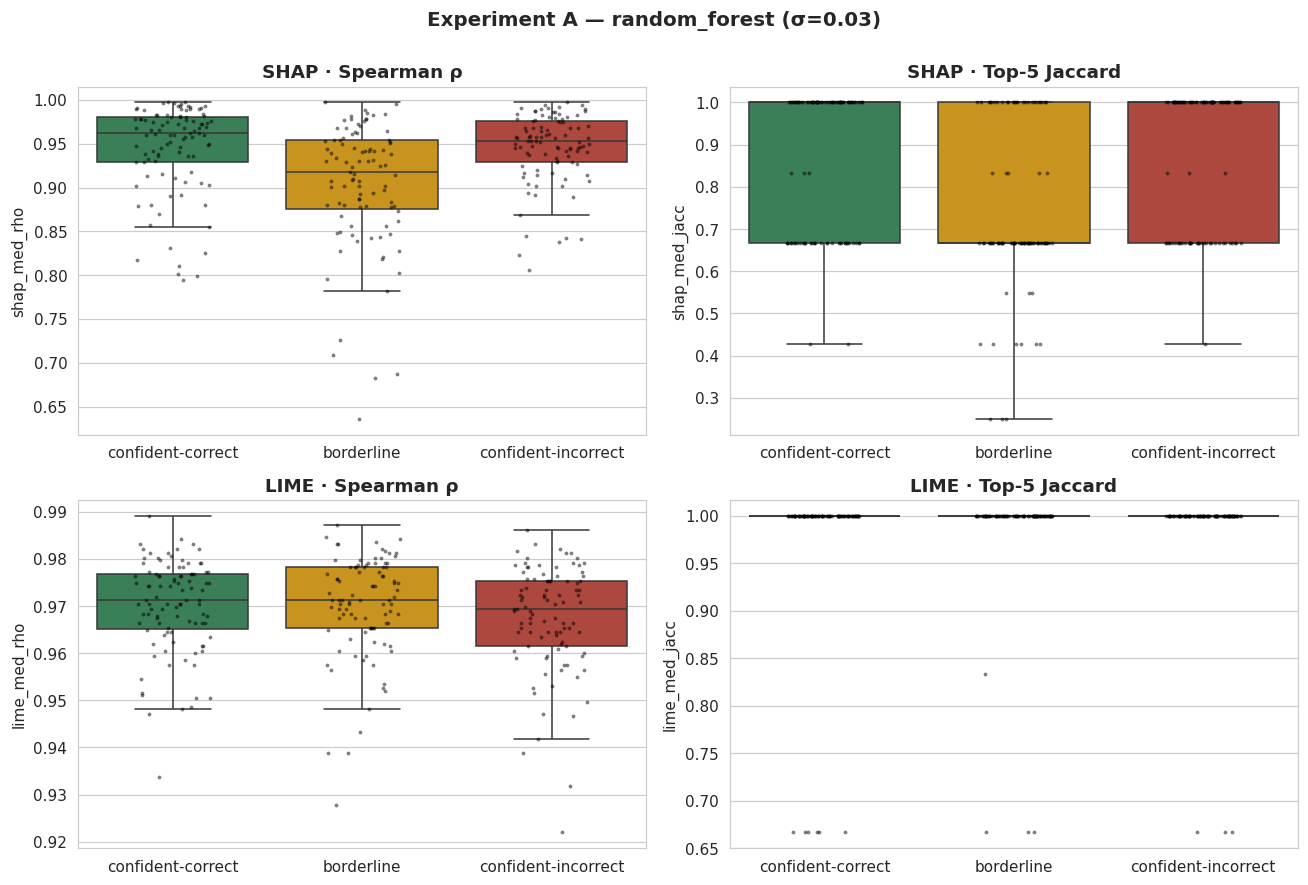

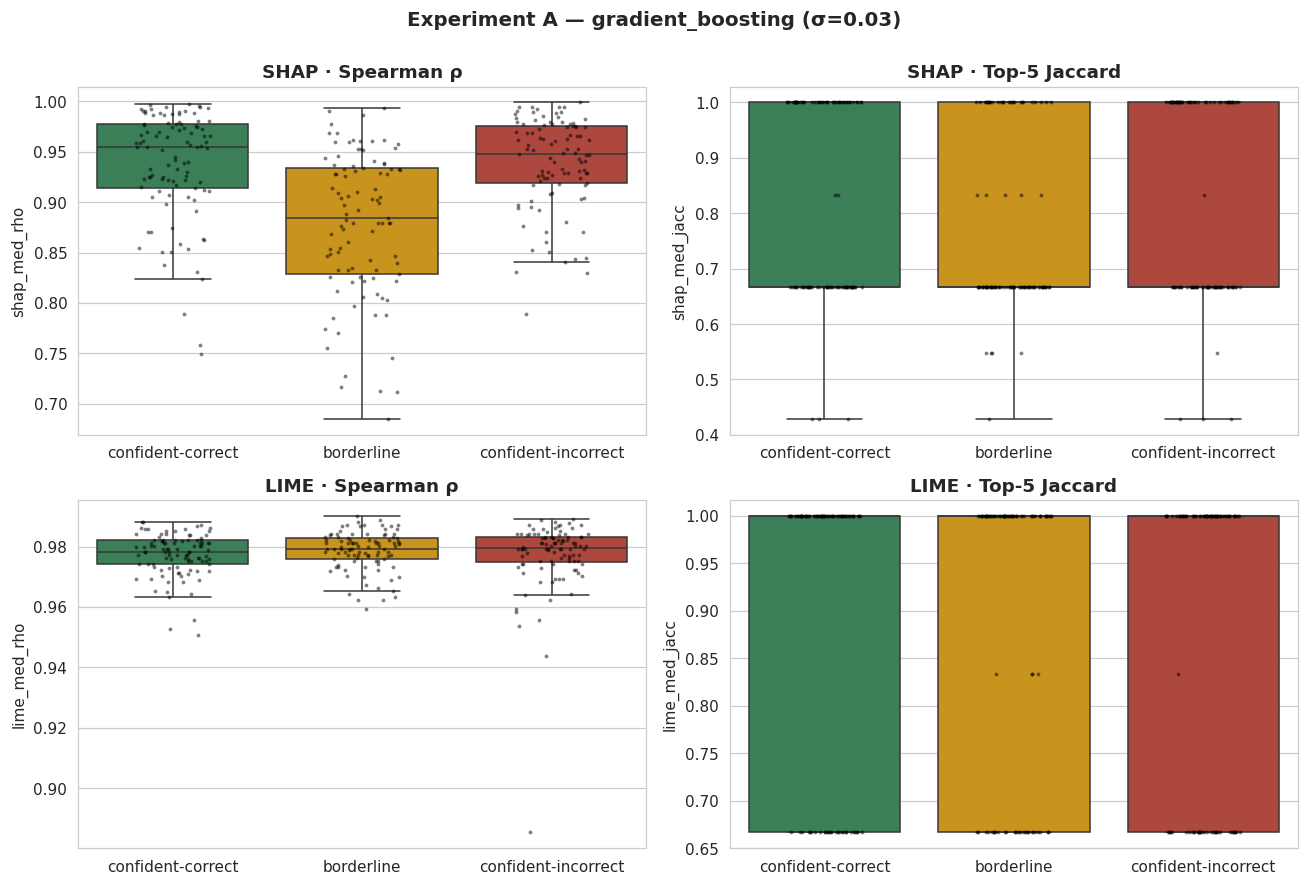

In [ ]:
def figure_expA_distributions(per_instance_df, model_name, sigma_label="0.03"):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    palette = [STRATUM_COLORS[s] for s in STRATUM_ORDER]
    for ax, (col, title) in zip(axes.flat, [
        ("shap_med_rho",   "SHAP · Spearman ρ"),
        ("shap_med_jacc",  "SHAP · Top-5 Jaccard"),
        ("lime_med_rho",   "LIME · Spearman ρ"),
        ("lime_med_jacc",  "LIME · Top-5 Jaccard"),
    ]):
        sns.boxplot(data=per_instance_df, x="stratum", y=col, order=STRATUM_ORDER,
                    ax=ax, palette=palette, showfliers=False)
        sns.stripplot(data=per_instance_df, x="stratum", y=col, order=STRATUM_ORDER,
                      ax=ax, color="black", size=2.5, jitter=0.2, alpha=0.5)
        ax.set_title(title); ax.set_xlabel(""); ax.set_ylabel(col)
        ax.set_xticklabels([s.replace("_","-") for s in STRATUM_ORDER])
    fig.suptitle(f"Experiment A — {model_name} (σ={sigma_label})",
                 y=1.00, fontsize=13, weight="bold")
    fig.tight_layout()
    out = FIGURES_DIR / f"expA_{model_name}_sigma{sigma_label}.png"
    fig.savefig(out, bbox_inches="tight")
    plt.show()


figure_expA_distributions(expA_rf,  "random_forest")
figure_expA_distributions(expA_gbm, "gradient_boosting")


### 11.2 · σ-sweep (RF only) — robustness check

  [Exp A · random_forest · σ=0.01] confident_correct: 100 instances
  [Exp A · random_forest · σ=0.01] borderline: 100 instances
  [Exp A · random_forest · σ=0.01] confident_incorrect: 100 instances


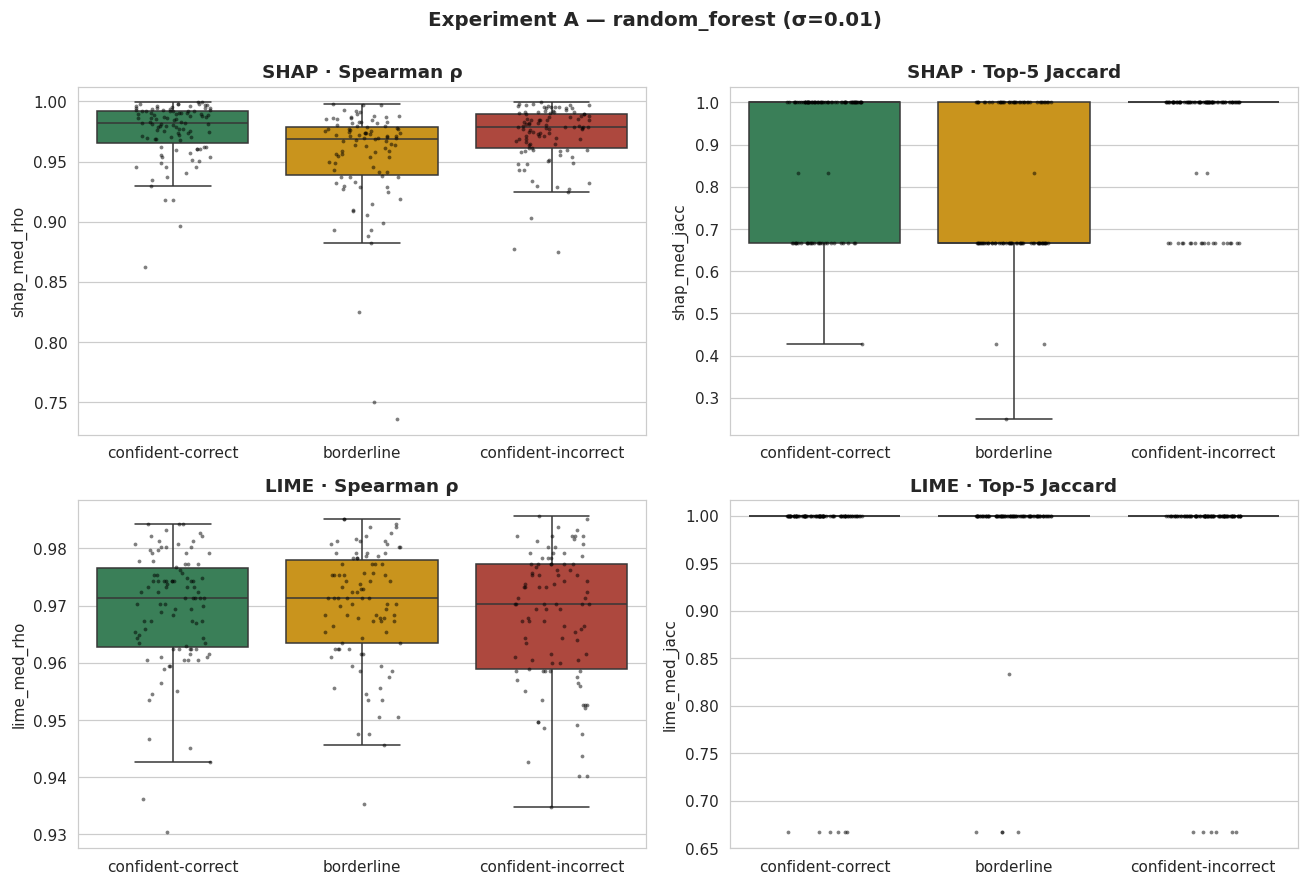

  [Exp A · random_forest · σ=0.05] confident_correct: 100 instances
  [Exp A · random_forest · σ=0.05] borderline: 100 instances
  [Exp A · random_forest · σ=0.05] confident_incorrect: 100 instances


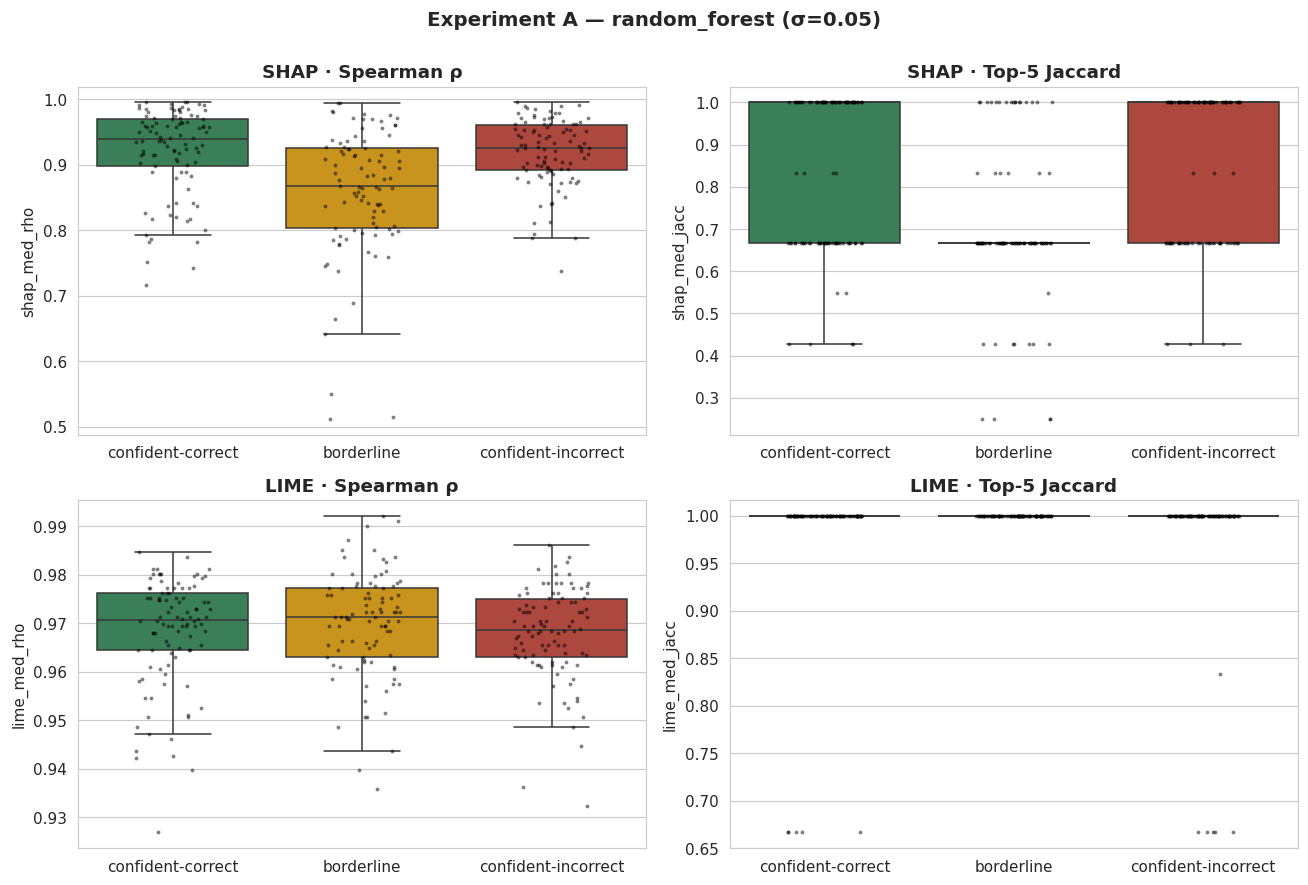


σ-sweep summary — head():


,stratum,shap_med_rho,shap_med_jacc,sigma
0,borderline,0.969,0.667,0.01
1,confident_correct,0.982,1.000,0.01
2,confident_incorrect,0.978,1.000,0.01
3,borderline,0.918,0.667,0.03
4,confident_correct,0.962,1.000,0.03
5,confident_incorrect,0.953,1.000,0.03
6,borderline,0.868,0.667,0.05
7,confident_correct,0.939,1.000,0.05
8,confident_incorrect,0.926,1.000,0.05


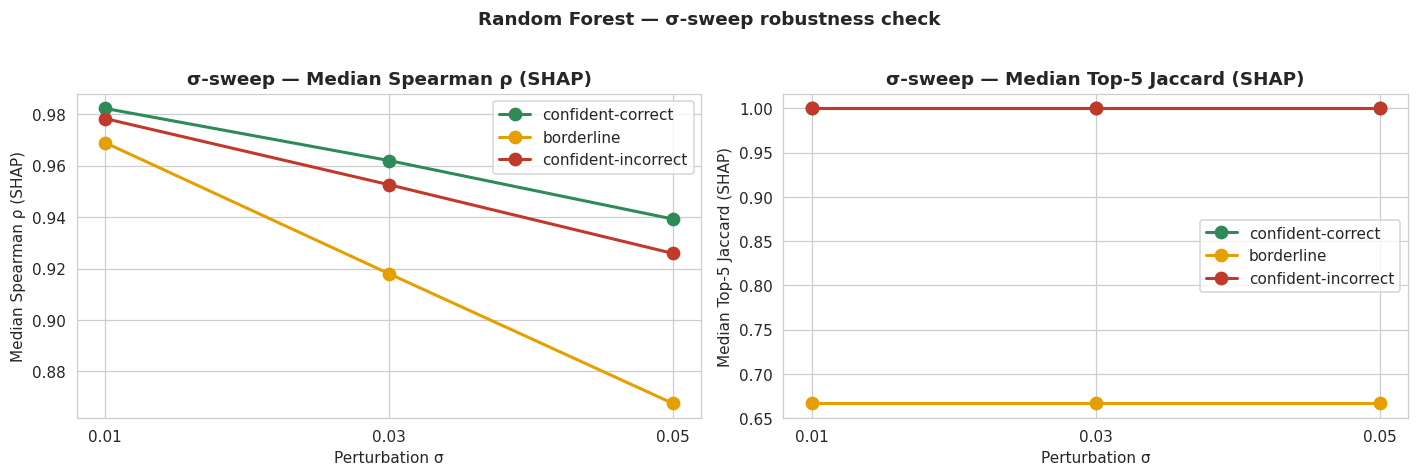

In [ ]:
sigma_summary = []
sigma_dfs = {}
for sigma in PERTURB_SIGMA_GRID:
    if sigma == PERTURB_SIGMA_HEADLINE:
        df_sigma = expA_rf
    else:
        pert = TypeAwarePerturber(X_train, sigma=sigma)
        df_sigma = run_experiment_A(rf, "random_forest", X_test, X_train, sample_rf, pert,
                                    sigma_label=f"{sigma}")
        df_sigma.to_csv(TABLES_DIR / f"expA_random_forest_sigma{sigma}_per_instance.csv",
                        index=False)
        figure_expA_distributions(df_sigma, "random_forest", sigma_label=f"{sigma}")
    sigma_dfs[sigma] = df_sigma
    med = (df_sigma.groupby("stratum")[["shap_med_rho","shap_med_jacc"]]
           .median().reset_index())
    med["sigma"] = sigma
    sigma_summary.append(med)

sigma_df = pd.concat(sigma_summary, ignore_index=True)
sigma_df.to_csv(TABLES_DIR / "sigma_sweep_summary.csv", index=False)

print("\nσ-sweep summary — head():")
display(sigma_df.round(3).head(10))

# Plot the sweep
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for ax, metric, ylabel in [
    (axes[0], "shap_med_rho",  "Median Spearman ρ (SHAP)"),
    (axes[1], "shap_med_jacc", "Median Top-5 Jaccard (SHAP)"),
]:
    pivot = sigma_df.pivot(index="sigma", columns="stratum", values=metric)
    pivot = pivot[STRATUM_ORDER]
    for s in STRATUM_ORDER:
        ax.plot(pivot.index, pivot[s], "o-", color=STRATUM_COLORS[s],
                lw=2, ms=8, label=s.replace("_","-"))
    ax.set_xlabel("Perturbation σ")
    ax.set_ylabel(ylabel)
    ax.set_title(f"σ-sweep — {ylabel}")
    ax.legend()
    ax.set_xticks(list(PERTURB_SIGMA_GRID))
fig.suptitle("Random Forest — σ-sweep robustness check", y=1.02, weight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "sigma_sweep.png", bbox_inches="tight")
plt.show()


## 12 · Experiment B — Cross-method agreement (SHAP vs LIME)

For each instance, compute SHAP and LIME attributions on the original (unperturbed) input. Report the pairwise Spearman ρ and Top-5 Jaccard between the two attribution vectors, summarised per stratum.

In [ ]:
def run_experiment_B(model, model_name, X_test, X_train, sample):
    shap_expl, lime_expl = build_explainers(model, X_train)
    rows = []
    n_feat = X_test.shape[1]
    for stratum, idx_list in sample.items():
        print(f"  [Exp B · {model_name}] {stratum}: {len(idx_list)} instances")
        for idx in idx_list:
            x = X_test.iloc[idx]
            phi_shap = shap_attribution(shap_expl, x)
            phi_lime = lime_attribution(lime_expl, model, x, n_feat)
            rows.append({
                "model": model_name, "stratum": stratum, "test_idx": idx,
                "shap_lime_rho":  spearman_rho(phi_shap, phi_lime),
                "shap_lime_jacc": top_k_jaccard(phi_shap, phi_lime, k=5),
            })
    return pd.DataFrame(rows)


expB_rf  = run_experiment_B(rf,  "random_forest",     X_test, X_train, sample_rf)
expB_gbm = run_experiment_B(gbm, "gradient_boosting", X_test, X_train, sample_gbm)
expB_rf.to_csv(TABLES_DIR  / "expB_random_forest_per_instance.csv",     index=False)
expB_gbm.to_csv(TABLES_DIR / "expB_gradient_boosting_per_instance.csv", index=False)

print("\nExp B · Random Forest — per-instance dataframe head():")
display(expB_rf.head())
print("\nExp B · Gradient Boosting — per-instance dataframe head():")
display(expB_gbm.head())

print("\nRF SHAP-vs-LIME medians:")
display(expB_rf.groupby("stratum")[["shap_lime_rho","shap_lime_jacc"]]
        .median().reindex(STRATUM_ORDER).round(3))
print("\nGBM SHAP-vs-LIME medians:")
display(expB_gbm.groupby("stratum")[["shap_lime_rho","shap_lime_jacc"]]
        .median().reindex(STRATUM_ORDER).round(3))


### 12.1 · Figure B — Cross-method agreement (heatmap + violin)

In [ ]:
def figure_expB_heatmap(per_instance_df, model_name):
    pivot = (per_instance_df.groupby("stratum")[["shap_lime_rho", "shap_lime_jacc"]]
             .median().reindex(STRATUM_ORDER))
    fig, ax = plt.subplots(figsize=(7, 3.2))
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap="RdYlGn",
                vmin=-1.0, vmax=1.0, ax=ax,
                cbar_kws={"label": "median agreement"},
                linewidths=0.5, linecolor="white")
    ax.set_title(f"Experiment B — SHAP vs LIME, {model_name}")
    ax.set_ylabel("Stratum")
    fig.tight_layout()
    out = FIGURES_DIR / f"expB_heatmap_{model_name}.png"
    fig.savefig(out, bbox_inches="tight")
    plt.show()


figure_expB_heatmap(expB_rf,  "random_forest")
figure_expB_heatmap(expB_gbm, "gradient_boosting")


# Violin plot showing the full distribution of cross-method agreement per stratum
def figure_expB_violin(expB_rf, expB_gbm):
    df_long = pd.concat([
        expB_rf.assign(model="Random Forest"),
        expB_gbm.assign(model="Gradient Boosting"),
    ], ignore_index=True)
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
    palette = [STRATUM_COLORS[s] for s in STRATUM_ORDER]
    for ax, metric, ylabel in [
        (axes[0], "shap_lime_rho",  "Spearman ρ (SHAP vs LIME)"),
        (axes[1], "shap_lime_jacc", "Top-5 Jaccard (SHAP vs LIME)"),
    ]:
        sns.violinplot(data=df_long, x="model", y=metric, hue="stratum",
                       hue_order=STRATUM_ORDER, palette=palette, ax=ax,
                       inner="quartile", cut=0)
        ax.set_title(ylabel)
        ax.set_ylabel(ylabel); ax.set_xlabel("")
        if metric == "shap_lime_rho":
            ax.axhline(0, color="black", lw=0.7, ls="--", alpha=0.6)
        ax.legend(title="Stratum", loc="lower right", fontsize=8)
    fig.suptitle("Experiment B — distribution of cross-method agreement",
                 y=1.02, weight="bold")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "expB_violin.png", bbox_inches="tight")
    plt.show()


figure_expB_violin(expB_rf, expB_gbm)


## 13 · Statistical tests (Mann–Whitney U + Holm–Bonferroni)

Each non-reference stratum is compared to Confident-Correct (the reference) using the Mann–Whitney U test, with Holm–Bonferroni correction across the two pairwise comparisons. Rank-biserial effect size is reported alongside.

In [ ]:
def rank_biserial(group1, group2):
    g1 = np.asarray(group1, dtype=float); g1 = g1[~np.isnan(g1)]
    g2 = np.asarray(group2, dtype=float); g2 = g2[~np.isnan(g2)]
    if len(g1) == 0 or len(g2) == 0:
        return np.nan
    u, _ = sp_stats.mannwhitneyu(g1, g2, alternative="two-sided")
    return 1.0 - (2.0 * u) / (len(g1) * len(g2))


def holm_bonferroni(p_values):
    p = np.asarray(p_values, dtype=float)
    m = len(p); order = np.argsort(p)
    adj = np.empty(m); running = 0.0
    for rank, i in enumerate(order):
        adj_p = min(p[i] * (m - rank), 1.0)
        running = max(running, adj_p)
        adj[i] = running
    return adj


def stratum_tests(per_instance_df, metric_col, ref=REFERENCE_STRATUM,
                  alternatives=("borderline", "confident_incorrect")):
    ref_vals = per_instance_df.loc[per_instance_df["stratum"] == ref, metric_col].values
    rows = []
    for alt in alternatives:
        alt_vals = per_instance_df.loc[per_instance_df["stratum"] == alt, metric_col].values
        if len(ref_vals) > 0 and len(alt_vals) > 0:
            try:
                _, pval = sp_stats.mannwhitneyu(ref_vals, alt_vals, alternative="two-sided")
            except ValueError:
                pval = np.nan
            rb = rank_biserial(ref_vals, alt_vals)
            ref_med, alt_med = float(np.nanmedian(ref_vals)), float(np.nanmedian(alt_vals))
        else:
            pval, rb, ref_med, alt_med = np.nan, np.nan, np.nan, np.nan
        rows.append({
            "metric": metric_col, "comparison": f"{ref} vs {alt}",
            "n_ref": len(ref_vals), "n_alt": len(alt_vals),
            "median_ref": ref_med, "median_alt": alt_med,
            "p_value_raw": pval, "rank_biserial": rb,
        })
    adj = holm_bonferroni([r["p_value_raw"] for r in rows])
    for r, a in zip(rows, adj):
        r["p_value_holm"] = a
        r["significant_alpha_0.05"] = a < ALPHA
    return pd.DataFrame(rows)


stat_tables = {}
for name, df_ in [("expA_rf", expA_rf), ("expA_gbm", expA_gbm)]:
    for metric in ["shap_med_rho", "shap_med_jacc", "lime_med_rho", "lime_med_jacc"]:
        t = stratum_tests(df_, metric); t["source"] = name
        stat_tables[f"{name}_{metric}"] = t

for name, df_ in [("expB_rf", expB_rf), ("expB_gbm", expB_gbm)]:
    for metric in ["shap_lime_rho", "shap_lime_jacc"]:
        t = stratum_tests(df_, metric); t["source"] = name
        stat_tables[f"{name}_{metric}"] = t

all_stats = pd.concat(stat_tables.values(), ignore_index=True)
all_stats.to_csv(TABLES_DIR / "stat_tests_all.csv", index=False)

print("Statistical tests — head():")
display(all_stats[["source","metric","comparison","median_ref","median_alt",
                   "p_value_holm","rank_biserial","significant_alpha_0.05"]]
        .round(4).head(12))


Statistical tests — head():


,source,metric,comparison,median_ref,median_alt,p_value_holm,rank_biserial,significant_alpha_0.05
0,expA_rf,shap_med_rho,confident_correct vs borderline,0.9620,0.9180,0.0,-0.4183,True
1,expA_rf,shap_med_rho,confident_correct vs confident_incorrect,0.9620,0.9526,0.0,-0.0893,True
2,expA_rf,shap_med_jacc,confident_correct vs borderline,1.0000,0.6667,0.0,-0.3660,True
3,expA_rf,shap_med_jacc,confident_correct vs confident_incorrect,1.0000,1.0000,0.0,0.0100,True
4,expA_rf,lime_med_rho,confident_correct vs borderline,0.9713,0.9713,0.0,0.0195,True
5,expA_rf,lime_med_rho,confident_correct vs confident_incorrect,0.9713,0.9694,0.0,-0.1380,True
6,expA_rf,lime_med_jacc,confident_correct vs borderline,1.0000,1.0000,0.0,0.0191,True
7,expA_rf,lime_med_jacc,confident_correct vs confident_incorrect,1.0000,1.0000,0.0,0.0300,True
8,expA_gbm,shap_med_rho,confident_correct vs borderline,0.9548,0.8844,1.0,-0.5085,False
9,expA_gbm,shap_med_rho,confident_correct vs confident_incorrect,0.9548,0.9481,1.0,-0.0102,False


### 13.1 · Visualize the statistical-test results

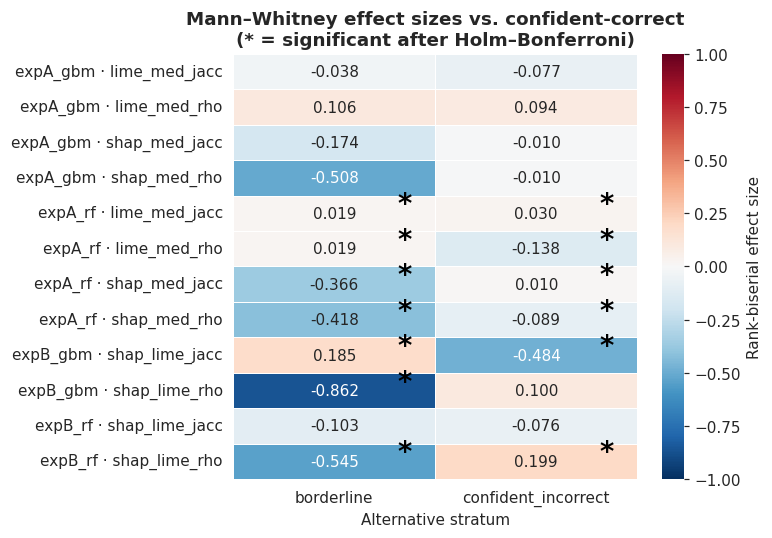

In [ ]:
# Heatmap of rank-biserial effect sizes, with significance markers
view = all_stats.copy()
view["alt"] = view["comparison"].str.split(" vs ").str[1]
view["src_metric"] = view["source"] + " · " + view["metric"]

pivot_rb  = view.pivot(index="src_metric", columns="alt", values="rank_biserial")
pivot_sig = view.pivot(index="src_metric", columns="alt", values="significant_alpha_0.05")

fig, ax = plt.subplots(figsize=(7, max(5, len(pivot_rb) * 0.36)))
sns.heatmap(pivot_rb, annot=True, fmt=".3f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, cbar_kws={"label": "Rank-biserial effect size"},
            ax=ax, linewidths=0.5, linecolor="white")
# Overlay stars on significant cells
for i, idx in enumerate(pivot_rb.index):
    for j, col in enumerate(pivot_rb.columns):
        if bool(pivot_sig.loc[idx, col]):
            ax.text(j + 0.85, i + 0.25, "*", color="black",
                    fontsize=18, fontweight="bold", ha="center", va="center")
ax.set_title("Mann–Whitney effect sizes vs. confident-correct\n(* = significant after Holm–Bonferroni)")
ax.set_xlabel("Alternative stratum"); ax.set_ylabel("")
plt.tight_layout()
plt.show()


## 14 · Summary figures

Side-by-side stratum medians for RF vs GBM, and global feature importance (mean |SHAP value|) across the test set.

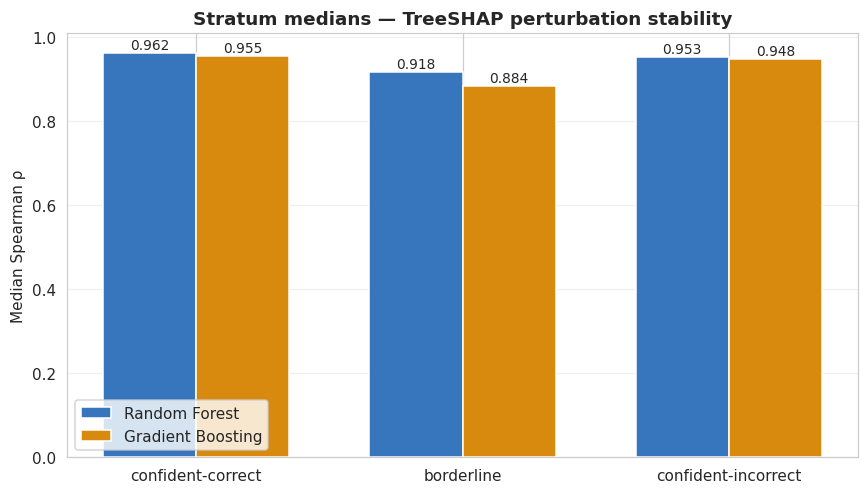

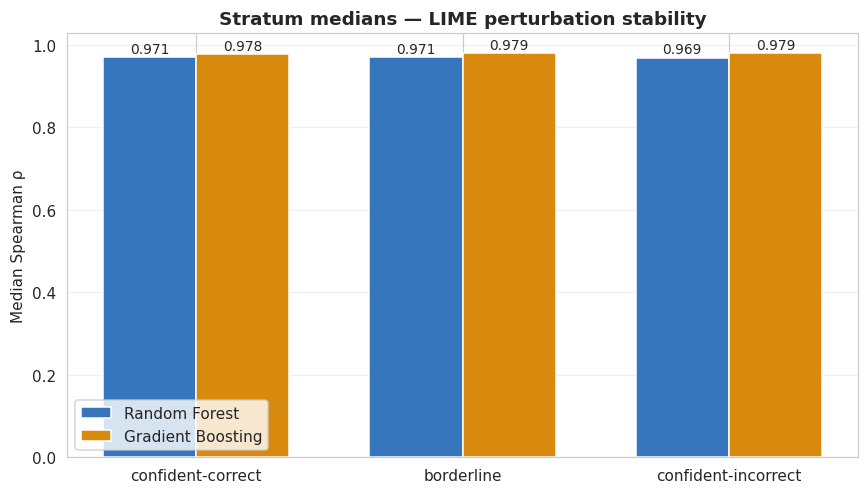

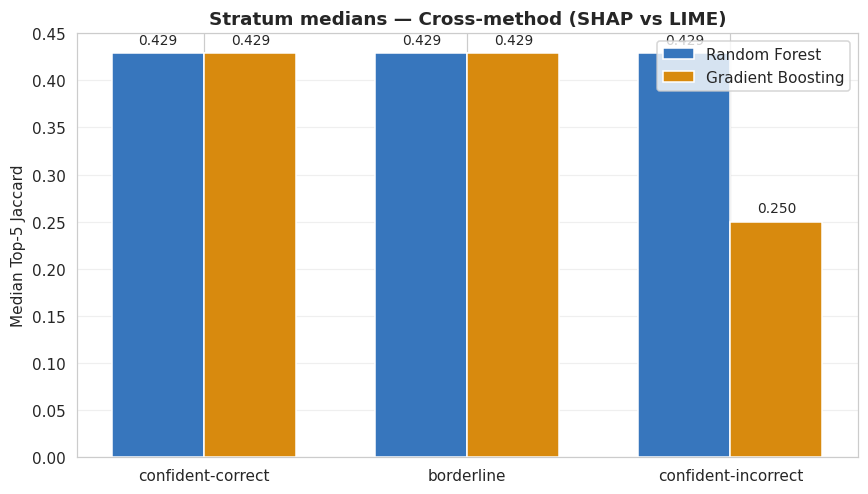

In [ ]:
def figure_summary_per_stratum(expA_rf, expA_gbm, metric_col, ylabel, title_suffix, fname):
    rf_ = expA_rf.groupby("stratum")[metric_col].median().reindex(STRATUM_ORDER)
    gb_ = expA_gbm.groupby("stratum")[metric_col].median().reindex(STRATUM_ORDER)
    fig, ax = plt.subplots(figsize=(8, 4.6))
    x = np.arange(len(STRATUM_ORDER)); w = 0.35
    ax.bar(x - w/2, rf_.values, width=w, label="Random Forest",     color="#3776BD")
    ax.bar(x + w/2, gb_.values, width=w, label="Gradient Boosting", color="#D88A0E")
    for i, (rfv, gbv) in enumerate(zip(rf_.values, gb_.values)):
        ax.text(i - w/2, rfv + 0.01, f"{rfv:.3f}", ha="center", fontsize=9)
        ax.text(i + w/2, gbv + 0.01, f"{gbv:.3f}", ha="center", fontsize=9)
    ax.set_xticks(x); ax.set_xticklabels([s.replace("_","-") for s in STRATUM_ORDER])
    ax.set_ylabel(ylabel); ax.set_title(f"Stratum medians — {title_suffix}")
    ax.legend(); ax.grid(True, axis="y", alpha=0.3)
    fig.tight_layout()
    out = FIGURES_DIR / fname
    fig.savefig(out, bbox_inches="tight")
    plt.show()


figure_summary_per_stratum(expA_rf, expA_gbm, "shap_med_rho",
                           "Median Spearman ρ", "TreeSHAP perturbation stability",
                           "summary_expA_shap_rho.png")
figure_summary_per_stratum(expA_rf, expA_gbm, "lime_med_rho",
                           "Median Spearman ρ", "LIME perturbation stability",
                           "summary_expA_lime_rho.png")
figure_summary_per_stratum(expB_rf, expB_gbm, "shap_lime_jacc",
                           "Median Top-5 Jaccard", "Cross-method (SHAP vs LIME)",
                           "summary_expB_jacc.png")


### 14.1 · Global feature importance (mean |SHAP value|)

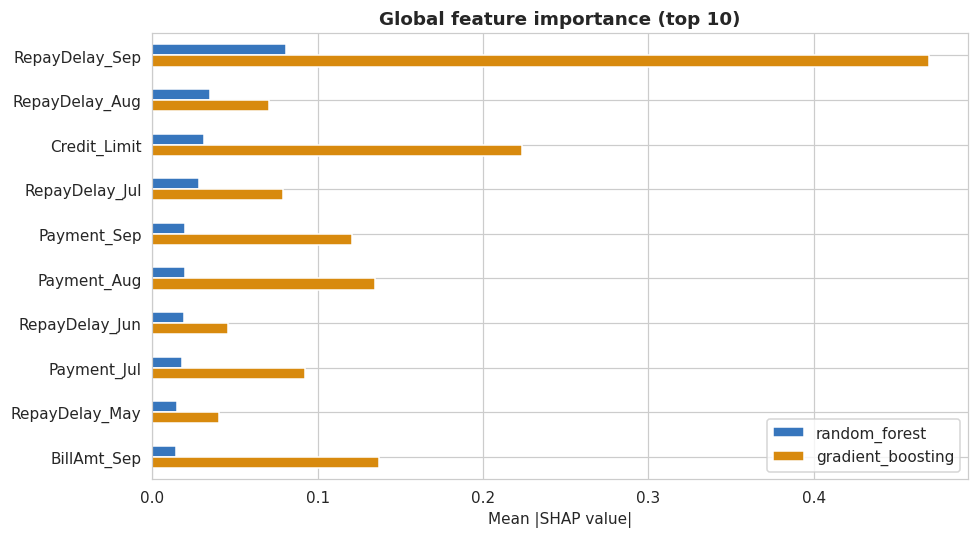

Global importance — head():


,random_forest,gradient_boosting
RepayDelay_Sep,0.0810,0.4699
RepayDelay_Aug,0.0349,0.0706
Credit_Limit,0.0315,0.2234
RepayDelay_Jul,0.0283,0.0789
Payment_Sep,0.0198,0.1210
Payment_Aug,0.0195,0.1348
RepayDelay_Jun,0.0194,0.0458
Payment_Jul,0.0181,0.0922
RepayDelay_May,0.0151,0.0401
BillAmt_Sep,0.0146,0.1373


In [ ]:
def figure_global_importance(models, X_test, top_n=10):
    rows = {}
    for name, model in models.items():
        try:
            expl = shap.TreeExplainer(model)
            sv = expl(X_test.iloc[:1000])
            v = sv.values
            if v.ndim == 3:
                v = v[:, :, 1]
            mean_abs = np.abs(v).mean(axis=0)
        except Exception as e:
            print(f"Global importance fallback for {name}: {e}")
            mean_abs = np.zeros(X_test.shape[1])
        rows[name] = pd.Series(mean_abs, index=X_test.columns)
    df = pd.DataFrame(rows).sort_values(list(rows.keys())[0], ascending=False).head(top_n)
    fig, ax = plt.subplots(figsize=(9, 5))
    df.plot.barh(ax=ax, color=["#3776BD", "#D88A0E"])
    ax.set_xlabel("Mean |SHAP value|")
    ax.set_title(f"Global feature importance (top {top_n})")
    ax.invert_yaxis()
    fig.tight_layout()
    out = FIGURES_DIR / "global_importance.png"
    fig.savefig(out, bbox_inches="tight")
    plt.show()
    df.to_csv(TABLES_DIR / "global_importance.csv")
    return df


gi_df = figure_global_importance({"random_forest": rf, "gradient_boosting": gbm}, X_test)
print("Global importance — head():")
display(gi_df.round(4).head(10))
